### HQ probes in OT NER data


* Define list of High Quality probes
* Find OT NEr subset with HQ probes
* Get all data for identified articles
* subset data for probe-target pairs (it has to be the correct target for the probe)
* Obtain triplets
* Improbe/update grounding
* Get grounded triplets

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm #SymLogNorm 
import matplotlib.colors 
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
from collections.abc import Iterable # To check for list-like objects
import re
import seaborn as sns
from collections import Counter
import numpy as np
import requests
import time
pd.set_option('display.max_colwidth', 200)

from tools import ChemblDB

pd.options.mode.chained_assignment = None 

In [3]:
#Counting probes in dictionary
hqprobes = pd.read_csv('data/probesSubset.csv', sep="\t")
#display(hqprobes)
nprobes = hqprobes.INCHI.nunique()
sprobes = hqprobes.assign(SYNOMS=hqprobes['SYNOMS'].str.split(',')).explode('SYNOMS').SYNOMS.nunique() 
print(nprobes, sprobes)


561 2797


In [4]:
display(hqprobes.columns)
hqprobes.PROBE.nunique()

Index(['SETID', 'UNIPROT', 'PROBE', 'SET', 'INCHI', 'GENE', 'CONTR',
       'CHEMBLID', 'PREF_NAME', 'SYNOMS', 'SYNOMS_TARGET'],
      dtype='object')

554

Probes in SGC (28): 101
Probes in Open Science (213): 112
Probes in ChemicalProbes Portal (408): 534
------------------------------


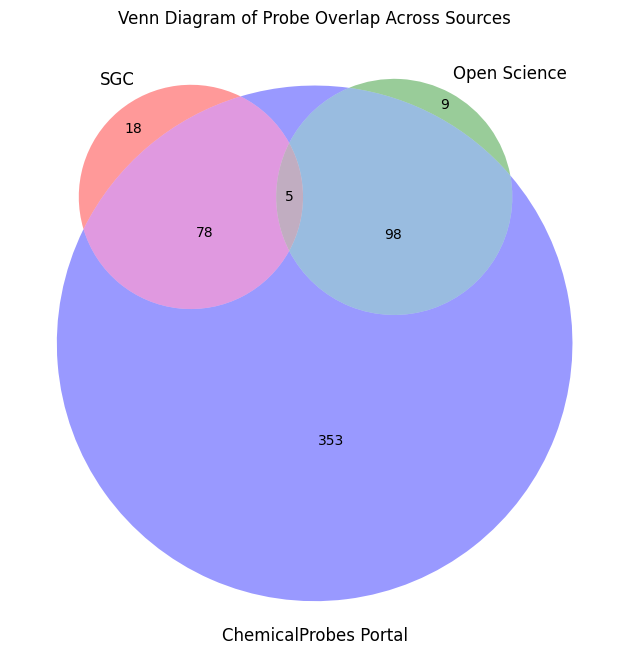

In [5]:
#Plot showing source of probes

subs = hqprobes[['INCHI','SETID']].drop_duplicates()

main_source_1 = 28
main_source_2 = 213
main_source_3 = 408

# Give names to your sources for the plot labels
source_1_name = 'SGC'
source_2_name = 'Open Science'
source_3_name = 'ChemicalProbes Portal'

# --- 3. Create Sets of probeIds for Each Main Source ---
set1 = set()
set2 = set()
set3 = set()

# Iterate through the DataFrame rows
for index, row in subs.iterrows():
    probe_id = row['INCHI']
    sources_entry = row['SETID']

    # Check if the sources_entry is a list/iterable (and not a string)
    if isinstance(sources_entry, Iterable) and not isinstance(sources_entry, str):
        # It's a list (or similar)
        if main_source_1 in sources_entry:
            set1.add(probe_id)
        if main_source_2 in sources_entry:
            set2.add(probe_id)
        if main_source_3 in sources_entry:
            set3.add(probe_id)
    else:
        # It's a single value
        if sources_entry == main_source_1:
            set1.add(probe_id)
        elif sources_entry == main_source_2:
            set2.add(probe_id)
        elif sources_entry == main_source_3:
            set3.add(probe_id)

print(f"Probes in {source_1_name} ({main_source_1}): {len(set1)}")
print(f"Probes in {source_2_name} ({main_source_2}): {len(set2)}")
print(f"Probes in {source_3_name} ({main_source_3}): {len(set3)}")
print("-" * 30)

# --- 4. Generate and Display the Venn Diagram ---
plt.figure(figsize=(10, 8)) # Adjust figure size as needed

# Create the Venn diagram using the sets
# venn3 automatically calculates the sizes of the intersections and unique parts
v = venn3(
    [set1, set2, set3],
    set_labels=(source_1_name, source_2_name, source_3_name)
)

plt.title('Venn Diagram of Probe Overlap Across Sources')
plt.savefig('figs/supp_vd_sources.png')
plt.show()


In [6]:
#numbers for initial dataset
#numbers1 = pd.read_csv('data/epmc_ner_results_hq_probes_all_sent.tsv', sep='\t')
#print(numbers1.pmid.nunique())
#print(numbers1.label.nunique())
#print(numbers1.label_id.nunique())

In [7]:
#Reading triplets data
ner_triplets = pd.read_csv('data/ner_probes_triplets.csv', sep="\t", dtype={'pmid': 'str', 'date':'str', 'section':'str', 'CD':'str', 'GP': 'str', 'DS':'str', 'sentence':'str'})

In [8]:
#Reading triplets with evidence data
ner_triplets_ptpairs = pd.read_csv('data/ner_probes_triplets_ptpairs_evd.csv', sep="\t")
print(len(ner_triplets_ptpairs))

820933


In [9]:
# mapping to terms for readability
rerun = False
targetsd = {}
diseasesd = {}
if rerun:
    def get_ensembl_gene_name(ensembl_id):
        """
        Fetches the gene name for a given Ensembl ID.
        """
        # The Ensembl REST API endpoint for looking up an ID
        api_url = f"https://rest.ensembl.org/lookup/id/{ensembl_id}?content-type=application/json"
        try:
            response = requests.get(api_url)
            # Raise an exception for bad status codes (4xx or 5xx)
            response.raise_for_status()
            data = response.json()
            # The gene name is usually in the 'display_name' field
            return data.get('display_name', 'N/A')
        except requests.exceptions.RequestException as e:
            print(f"Error fetching data for {ensembl_id}: {e}")
            return "Error"
        # Add a small delay to be respectful to the API server
        time.sleep(0.1)

    def get_ontology_term_name(term_id):
        """
        Fetches the term name for a given ontology ID (MONDO, EFO, HP) by constructing
        the correct IRI based on the ID's prefix.
        """
        if not isinstance(term_id, str):
            return "Invalid ID"
            
        term_id_clean = term_id.replace(':', '_')
        prefix = term_id_clean.split('_')[0].lower()

        # Define ontology-specific information
        ontology_config = {
            'efo': {
                'iri_base': 'http://www.ebi.ac.uk/efo/',
                'ontology_id': 'efo'
            },
            'mondo': {
                'iri_base': 'http://purl.obolibrary.org/obo/',
                'ontology_id': 'mondo'
            },
            'hp': {
                'iri_base': 'http://purl.obolibrary.org/obo/',
                'ontology_id': 'hp'
            }
        }

        if prefix not in ontology_config:
            print(f"Unknown prefix for term ID: {term_id}")
            return "Unknown Prefix"

        config = ontology_config[prefix]
        
        # 1. Construct the correct IRI
        term_iri = f"{config['iri_base']}{term_id_clean}"
        
        # 2. Double URL encode the IRI for the OLS API
        encoded_iri = requests.utils.quote(requests.utils.quote(term_iri, safe=''), safe='')
        
        # 3. Construct the final API URL
        api_url = f"https://www.ebi.ac.uk/ols/api/ontologies/{config['ontology_id']}/terms/{encoded_iri}"
        
        try:
            response = requests.get(api_url, timeout=10)
            # Add a small delay to be polite to the API
            time.sleep(0.1) 
            
            if response.status_code == 200:
                data = response.json()
                return data.get('label', 'N/A').lower()
            else:
                print(f"Failed for {term_id}: Status {response.status_code} from {api_url}")
                return "Not Found"
                
        except requests.exceptions.RequestException as e:
            print(f"Request exception for {term_id}: {e}")
            return "Request Error"
    # --- Mapping the IDs ---

    for tar in ner_triplets_ptpairs.targetId.unique().tolist():
        tarn = get_ensembl_gene_name(tar)
        targetsd[tar] = tarn
    
    for dis in ner_triplets_ptpairs.diseaseId.unique().tolist():
        disn = get_ontology_term_name(dis)
        diseasesd[dis] = disn


    # Apply the functions to the DataFrame columns
    # Using .loc to avoid SettingWithCopyWarning
    ner_triplets_ptpairs.loc[:, 'targetName'] = ner_triplets_ptpairs['targetId'].map(targetsd)
    ner_triplets_ptpairs.loc[:, 'diseaseName'] = ner_triplets_ptpairs['diseaseId'].map(diseasesd)

    ner_triplets_ptpairs.to_csv('data/ner_probes_triplets_ptpairs_evd.csv', sep="\t", index=False)
else:
    ner_triplets_ptpairs = pd.read_csv('data/ner_probes_triplets_ptpairs_evd.csv', sep="\t")

In [10]:
display(ner_triplets_ptpairs.head(1))

,diseaseId,targetId,datasourceId,allcurationYears,allpublicationYears,allstudyYears,datatypeId,score,evidenceCount,pmid,...,inchiKey,gene,control,prefName,probeSyn,targetSyn,maxPhase,target-disease,targetName,diseaseName
0,DOID_7551,ENSG00000121879,europepmc,NaN,"[2021, 2016, 2014, 2012, 2019, 2020, 2023, 2013, 2018, 2022, 2015, 2011, 2017]",NaN,literature,0.515801,135.0,31662821,...,STUWGJZDJHPWGZ-LBPRGKRZSA-N,PIK3CA,NaN,ALPELISIB,"VIJOICE, A-1214, Byl-719, (S)-N1-(4-Methyl-5-(2-(1,1,1-trifluoro-2-methylpropan-2-yl)pyridin-4-yl)thiazol-2-yl)pyrrolidine-1,2-dicarboxamide, Alpelisib (BYL719), NVP-BYL719, Vijoice, Piqray, PIQRA...","Phosphoinositide 3-kinase alpha, Phosphatidylinositol 4,5-bisphosphate 3-kinase 110 kDa catalytic subunit alpha, PI3K-alpha, PI3-kinase subunit alpha, Phosphoinositide-3-kinase catalytic alpha pol...",4.0,ENSG00000121879-DOID_7551,PIK3CA,Unknown Prefix


In [11]:
#showing numbers for any probe-target found
print('any probe-target')
print(len(ner_triplets))
for col in ner_triplets:
    print(col, ner_triplets[col].nunique())
print('\n')

#showing numbers for the speicifc known target for the probe
print('specific probe-target')
print(len(ner_triplets_ptpairs))
for col in ner_triplets_ptpairs:
    print(col, ner_triplets_ptpairs[col].nunique())

any probe-target
1413366
pmid 103381
date 4494
section 39
CD 5709
GP 9238
DS 3574
sentence 425506


specific probe-target
820933
diseaseId 1353
targetId 161
datasourceId 23
allcurationYears 73
allpublicationYears 3545
allstudyYears 790
datatypeId 7
score 6997
evidenceCount 851
pmid 19999
date 1932
section 27
probeId 194
sentence 39124
setId 3
uniprot 463
probe 194
set 3
inchiKey 194
gene 161
control 39
prefName 141
probeSyn 211
targetSyn 353
maxPhase 4
target-disease 5556
targetName 161
diseaseName 1284


In [12]:
#cleaning wrong disease ids
display(ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.contains('CHEMBL')].iloc[:, : 7].drop_duplicates(subset='diseaseId'))
ner_triplets_ptpairs = ner_triplets_ptpairs.drop(ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.contains('CHEMBL')].index)

,diseaseId,targetId,datasourceId,allcurationYears,allpublicationYears,allstudyYears,datatypeId


In [13]:
#showing weird ids in data
display(ner_triplets_ptpairs[ner_triplets_ptpairs['diseaseId'].str.startswith('OTAR')].iloc[:, : 7].drop_duplicates(subset='diseaseId'))

,diseaseId,targetId,datasourceId,allcurationYears,allpublicationYears,allstudyYears,datatypeId
264431,OTAR_0000003,ENSG00000171608,europepmc,NaN,[2017],NaN,literature


In [14]:
#Clean columns names
#ner_triplets_ptpairs = ner_triplets_ptpairs.rename(columns={'probe':'PROBE_NAME'}).rename(columns={'pmid':'PMID', 'CD': 'PROBE', 'GP': 'TARGET', 'DS':'DISEASES'})
display(ner_triplets_ptpairs.head(1))

,diseaseId,targetId,datasourceId,allcurationYears,allpublicationYears,allstudyYears,datatypeId,score,evidenceCount,pmid,...,inchiKey,gene,control,prefName,probeSyn,targetSyn,maxPhase,target-disease,targetName,diseaseName
0,DOID_7551,ENSG00000121879,europepmc,NaN,"[2021, 2016, 2014, 2012, 2019, 2020, 2023, 2013, 2018, 2022, 2015, 2011, 2017]",NaN,literature,0.515801,135.0,31662821,...,STUWGJZDJHPWGZ-LBPRGKRZSA-N,PIK3CA,NaN,ALPELISIB,"VIJOICE, A-1214, Byl-719, (S)-N1-(4-Methyl-5-(2-(1,1,1-trifluoro-2-methylpropan-2-yl)pyridin-4-yl)thiazol-2-yl)pyrrolidine-1,2-dicarboxamide, Alpelisib (BYL719), NVP-BYL719, Vijoice, Piqray, PIQRA...","Phosphoinositide 3-kinase alpha, Phosphatidylinositol 4,5-bisphosphate 3-kinase 110 kDa catalytic subunit alpha, PI3K-alpha, PI3-kinase subunit alpha, Phosphoinositide-3-kinase catalytic alpha pol...",4.0,ENSG00000121879-DOID_7551,PIK3CA,Unknown Prefix


In [15]:
print(ner_triplets_ptpairs.pmid.nunique(), ner_triplets_ptpairs.probe.nunique(), ner_triplets_ptpairs.targetId.nunique(), ner_triplets_ptpairs.diseaseId.nunique() )

19999 194 161 1353


In [16]:
ner_triplets_ptpairs.columns

Index(['diseaseId', 'targetId', 'datasourceId', 'allcurationYears',
       'allpublicationYears', 'allstudyYears', 'datatypeId', 'score',
       'evidenceCount', 'pmid', 'date', 'section', 'probeId', 'sentence',
       'setId', 'uniprot', 'probe', 'set', 'inchiKey', 'gene', 'control',
       'prefName', 'probeSyn', 'targetSyn', 'maxPhase', 'target-disease',
       'targetName', 'diseaseName'],
      dtype='object')

In [18]:
#Subset with target-disease pairs having 100 or more articles found (probably to be used to construct a netweor)
subs2 = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO', 'HP'), na=False)][['targetId', 'diseaseId', 'probeId', 'pmid']]
#print(subs.head())

# 1. Aggregate data
grouped_data2 = subs2.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', pd.Series.nunique),
    probeId_count=('probeId', pd.Series.nunique)
).reset_index()

grouped_data2 = grouped_data2[grouped_data2.pmid_count>=100]
display(grouped_data2.sort_values(by='probeId_count',ascending=False).head())
print(len(grouped_data2))
grouped_data2.to_csv("/Users/adasme/Documents/codes/probes_articles/figs/tables/subset_100freq.tsv", sep='\t', index=False)

,targetId,diseaseId,pmid_count,probeId_count
1362,ENSG00000106462,MONDO_0004992,123,5
1254,ENSG00000106462,EFO_0000403,100,5
1261,ENSG00000106462,EFO_0000616,247,5
2748,ENSG00000143799,MONDO_0004992,141,5
2289,ENSG00000135679,MONDO_0004992,102,5


60


#### Sections in articles

,section,counts
0,abbr,99
1,abstract,7938
2,ack_fund,13
3,auth_cont,2
4,case,47
5,concl,1529
6,discuss,10050
7,fig,622
8,intro,9357
9,methods,2747


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/4131460305.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['section'], rotation=45, ha='right')


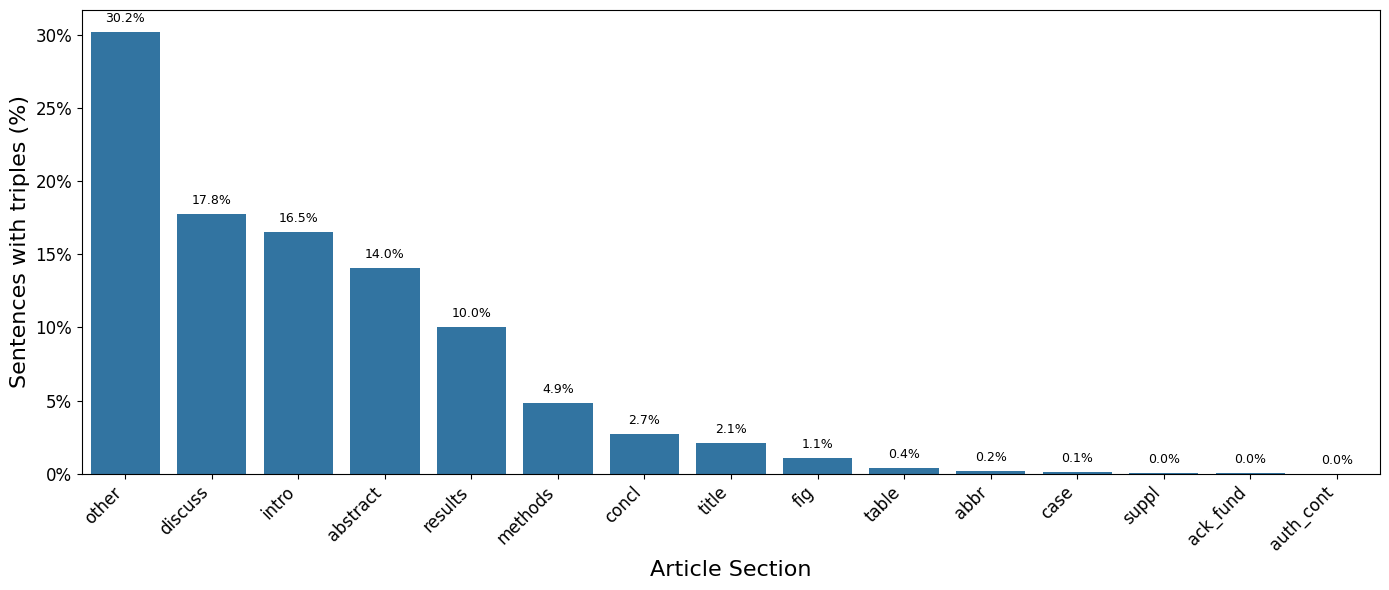

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter # Import the formatter

# 1. Ensure the 'section' column is string type and handle potential missing values
articles = ner_triplets_ptpairs[['diseaseId', 'targetId','pmid','section', 'probeId', 'sentence']].drop_duplicates().dropna(subset=['section']).copy() # Drop rows where section is NaN
articles['section'] = articles['section'].astype(str) 

# 2. Split the 'section' string by comma into a list of strings
#    Use str.strip() within a list comprehension to remove leading/trailing whitespace 
#    from each section name after splitting.
articles['section'] = articles['section'].str.split(',').apply(lambda x: [item.strip() for item in x])

# 3. Explode the DataFrame based on the 'section' list
#    This creates a new row for each item in the list in the 'section' column,
#    duplicating the other column values for that original row.
articles_exploded = articles.explode('section')

secs = articles_exploded.drop_duplicates().groupby('section')['sentence'].count().reset_index(name='counts')
display(secs)
df = secs.sort_values('counts', ascending=False)


# --- New: Calculate percentages ---
total_counts = df['counts'].sum()
df['percentage'] = (df['counts'] / total_counts) * 100

# --- Plotting Code ---
plt.figure(figsize=(14, 6))

# --- Modified: Use 'percentage' for the y-axis ---
ax = sns.barplot(x='section', y='percentage', data=df)

# Rotate x-axis labels
ax.tick_params(axis='x', rotation=45)

# --- Modified: Format Y-axis to show percentages ---
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))

# --- Modified: Set Y-axis label to indicate percentage ---
ax.set_ylabel("Sentences with triples (%)", fontsize=16)
ax.set_xlabel("Article Section", fontsize=16)

# This part needs to be adjusted based on the actual sections in your data
# For the sample data, we'll get the labels from the DataFrame
ax.set_xticklabels(df['section'], rotation=45, ha='right')


# Increase font size for tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- Modified: Add annotations with percentage values ---
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9)

# Adjust layout
plt.tight_layout() 

plt.savefig("figs/sections.png", dpi=400)
# Display the plot
plt.show()

In [20]:
# Examples with sentences found in the "Other" category of the article sections
articles_exploded[articles_exploded.section == 'other'][['pmid','sentence']].head(10)

,pmid,sentence
0,31662821,"A clinical trial (NCT01613950) was performed to investigate the efficacy of the combination of alpelisib (BYL719), a potent and selective inhibitor of mutated PI3KCA and AUY922, an inhibitor of he..."
1,33321820,"Some clinical trials of PI3K inhibitors (BKM120, BYL719, and GSK2636771) and Akt inhibitors (MK2206, GSK2110183, and GDC-0068; Table 3) have been performed in patients with advanced and metastatic..."
5,26267324,"To date, two classes of PI3K inhibitors have been evaluated for the treatment of GC: pan-PI3K inhibitors, which target all PI3K family members (BKM120, PX-886, and XL147), and isoform-specific PI3..."
8,38339127,"A phase IB, multicenter, open-label dose escalation study tested the antitumoral effects of BYL719 (PI3K inhibitor) in combination with AUY922 (HSP90 inhibitor) in advanced or metastatic GC patien..."
17,26267324,"Currently, the isoform-specific p110α inhibitor, BYL719, and the heat shock protein 90 inhibitor, AUY922, are being evaluated in a phase I trial with advanced stage GC patients that carry either a..."
45,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."
46,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."
86,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."
89,27529512,"Thus, with the exception of flavopiridol for the treatment of chronic lymphocytic leukaemia (Lin et al, 2009), where the transcriptional kinase CDK9 is thought to be the primary target, and palboc..."
91,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."


#### Getting table with triplets (should be adapted to data)

In [21]:
grouped_df = ner_triplets_ptpairs.groupby(['probe', 'targetId']).agg({
    'diseaseId': lambda x: ', '.join([f'{item}[{count}]' for item, count in Counter(x).items()]),
    'pmid': 'nunique'
}).sort_values(by=['pmid']).reset_index()

# Rename aggregated columns
#grouped_df.columns = ['PROBE', 'GENE', 'ALL_DISEASES', 'ARTICLES']
grouped_df = grouped_df.rename(columns={'pmid':'articles'})
#display(grouped_df)

In [22]:
grouped_df2 = ner_triplets_ptpairs.groupby(['targetId', 'diseaseId']).agg({
    'probeId': lambda x: ', '.join([f'{item}[{count}]' for item, count in Counter(x).items()]),
    'pmid': 'nunique'
}).sort_values(by=['pmid']).reset_index()

# Rename aggregated columns
#grouped_df.columns = ['PROBE', 'GENE', 'ALL_DISEASES', 'ARTICLES']
grouped_df2 = grouped_df2.rename(columns={'pmid':'articles'})
sample = grouped_df2.sort_values(by='articles', ascending=False).head(100)
display(sample)
sample.to_csv('tables/ner_target_disease_pairs.csv', sep='\t', index=False)

,targetId,diseaseId,probeId,articles
5555,ENSG00000146648,EFO_0003060,"CHEMBL1173655[71952], CHEMBL5194790[24]",1260
5554,ENSG00000198793,EFO_0000616,"CHEMBL413[31806], CHEMBL1801204[2835], CHEMBL1922094[837], CHEMBL2336325[1161]",978
5553,ENSG00000198793,MONDO_0004992,"CHEMBL413[24867], CHEMBL1922094[459], CHEMBL1801204[1026], CHEMBL2336325[351]",825
5552,ENSG00000171791,EFO_0000222,CHEMBL3137309[19290],807
5551,ENSG00000171094,EFO_0003060,CHEMBL1738797[27852],804
...,...,...,...,...
5460,ENSG00000146648,EFO_0000228,CHEMBL1173655[1560],62
5459,ENSG00000096968,EFO_0000616,"CHEMBL1789941[2790], CHEMBL221959[270], CHEMBL2107823[90], CHEMBL3545215[180]",61
5458,ENSG00000066468,EFO_0000616,CHEMBL1852688[2054],61
5457,ENSG00000105639,EFO_0003778,CHEMBL221959[372],59


In [23]:
# --- Mapping the probe names ---
run=False
if run:
    probe_dictionary = ner_triplets_ptpairs.set_index('probeId')['probe'].to_dict()
    sample_exploded = sample['probeId'].str.split(',').explode().str.strip()
    def get_mapped_name(probe_entry):
        match = re.match(r'([^\[]+)(\[\d+\])', str(probe_entry))
        probe_id, count_in_brackets = match.groups()
        probe_name = probe_dictionary.get(probe_id, probe_id)
        return f"{probe_name.lower()}{count_in_brackets}"

    mapped_probes = sample_exploded.apply(get_mapped_name)
    aggregated_names = mapped_probes.groupby(level=0).agg(', '.join)
    sample['probeName'] = aggregated_names
    #sample = sample.drop_duplicates(subset=['targetName', 'diseaseName', 'probeName', 'articles']) #Some rows are repeated for same terms but different ids. The count of artiles, however is the same.
    sample = sample.merge(ner_triplets_ptpairs[['targetId', 'targetName']], on='targetId', how='left')
    sample = sample.merge(ner_triplets_ptpairs[['diseaseId', 'diseaseName']], on='diseaseId', how='left')

    # --- Display Results ---
    print("DataFrame with Mapped Names:")
    display(sample.head(1))

    # wrtites subset to use in table manuscript
    sample[['targetName', 'diseaseName', 'probeName', 'articles']].to_csv('tables/ner_target_disease_pairs_hr.csv', sep='\t', index=False)

#### Getting heatmap with Disease-target pairs (should be adapted to data)

3946 1


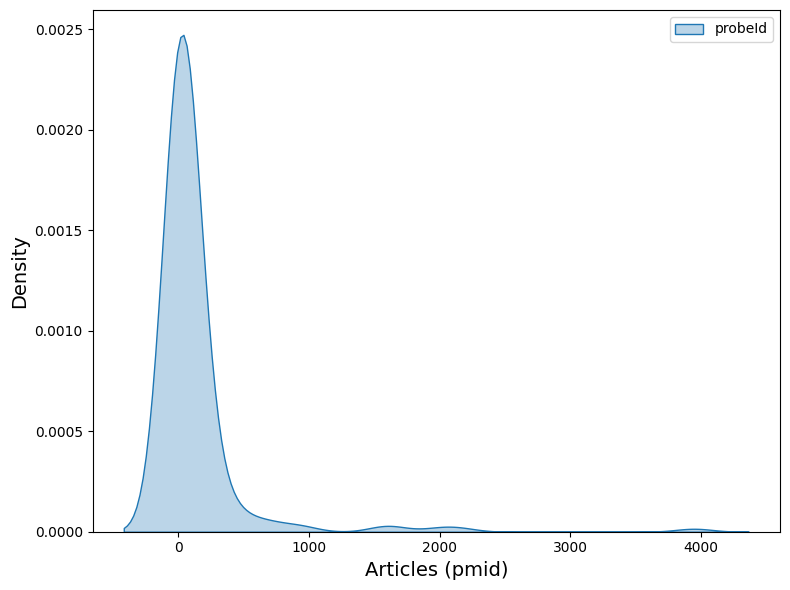

In [24]:
# Loop through the columns you want to plot
gr = ner_triplets_ptpairs.groupby('probeId').agg({'pmid': 'nunique'}).sort_values(by=['pmid']).reset_index()
print(gr.pmid.max(), gr.pmid.min())


# Create the figure and axes
plt.figure(figsize=(8, 6)) # Optional: Adjust figure size
# Use sns.kdeplot, specifying the data column and adding a label
sns.kdeplot(gr, x='pmid', label='probeId', fill=True, alpha=0.3, common_norm=False) # 'fill' adds shading
    

plt.xlabel('Articles (pmid)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("figs/ner_probes_pmid_distribution.png", dpi=400)
plt.savefig("figs/ner_probes_pmid_distribution.svg", dpi=400)
plt.show()

In [25]:
probe_dis = ner_triplets_ptpairs.groupby('probeId')[['targetId','diseaseId']].nunique().sort_values(by=['targetId']).reset_index()
print(probe_dis.targetId.min(),probe_dis.targetId.max(),probe_dis.targetId.median(),probe_dis.diseaseId.min(),probe_dis.diseaseId.max(),probe_dis.diseaseId.median())
#probe_dis = ner_triplets_ptpairs.groupby('probeId').agg({'diseaseId': 'nunique'}).sort_values(by=['pmid']).reset_index()

1 5 1.0 1 744 10.0


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/3730753049.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=probe_dis,
/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/3730753049.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=probe_dis,


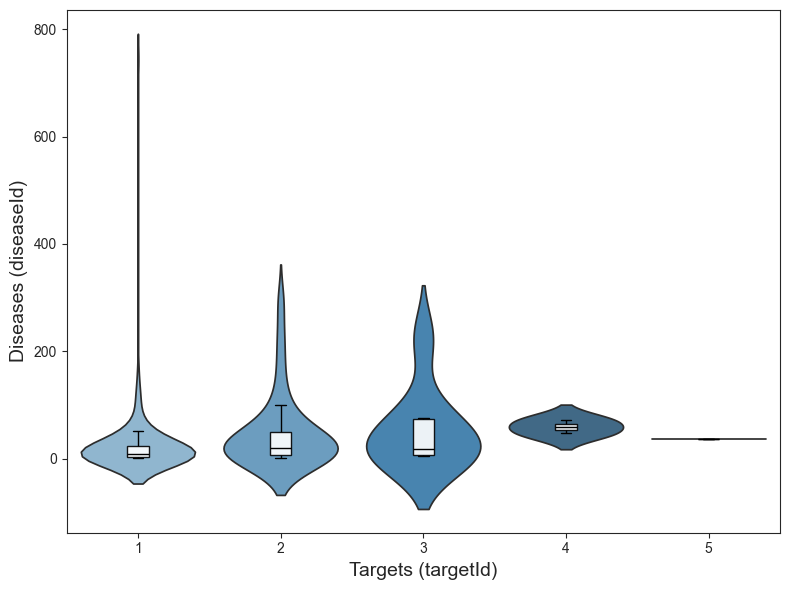

In [26]:
# Set the aesthetic style
sns.set_style("ticks")

# Create the figure and axes
plt.figure(figsize=(8, 6)) # Optional: Adjust figure size
ax = plt.gca() # Get the current axes

# 1. Create the violin plot WITHOUT the inner element
sns.violinplot(data=probe_dis,
               x='targetId',
               y='diseaseId',
               inner=None,       # Draw violin shape only
               palette='Blues_d',# Use the palette for violin color
               ax=ax)            # Specify the axes to draw on

# 2. Overlay the boxplot with custom styling
sns.boxplot(data=probe_dis,
            x='targetId',
            y='diseaseId',
            showfliers=False,   # Hide outliers here (violin shows full range)
            width=0.15,         # Make boxes narrow to fit inside violins
            palette='Blues_d',  # Use same palette for consistency (optional)
            boxprops=dict(facecolor='white', edgecolor='black', alpha=0.9), # *** Set facecolor to white ***
            medianprops=dict(color='black'), # Style median line
            whiskerprops=dict(color='black'),# Style whiskers
            capprops=dict(color='black'),    # Style caps
            ax=ax)              # Specify the same axes

# Improve appearance
sns.despine()

# Set labels and layout
plt.xlabel('Targets (targetId)', fontsize=14)
plt.ylabel('Diseases (diseaseId)', fontsize=14)

# --- Ensure all four spines are visible to form a box ---
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()


# Save and show the figure (updated filename)
plt.savefig("figs/ner_probe_tar_dis_distribution.png", dpi=400)
plt.savefig("figs/ner_probe_tar_dis_distribution.svg", dpi=400)
plt.show()

In [27]:
#checking the 3 most frequents disease in the heatmap
grt = ner_triplets_ptpairs.groupby(['diseaseId']).agg({'targetId': 'nunique'}).sort_values(by=['targetId']).reset_index()
print(grt[grt.diseaseId.isin(['EFO_0003060','EFO_0000616','MONDO_0004992'])])

          diseaseId  targetId
1348    EFO_0003060        58
1351  MONDO_0004992        97
1352    EFO_0000616       106


In [28]:
gr = ner_triplets_ptpairs.groupby(['targetId', 'diseaseId']).agg({'pmid': 'nunique'}).sort_values(by=['pmid']).reset_index()
print(gr.pmid.min(),gr.pmid.max())
grs = gr[gr.pmid>50]
#display(grs)
print(grs.targetId.nunique(), grs.diseaseId.nunique())
pivot_table = grs.pivot_table(index="targetId", columns="diseaseId", values="pmid")

1 1260
28 45


,targetId,diseaseId,pmid_count,probeId_count
1261,ENSG00000106462,EFO_0000616,247,5
1254,ENSG00000106462,EFO_0000403,100,5
1912,ENSG00000129484,MONDO_0004992,32,5
1901,ENSG00000129484,EFO_0000616,22,5
1362,ENSG00000106462,MONDO_0004992,123,5


<Axes: xlabel='pmid_count', ylabel='Count'>

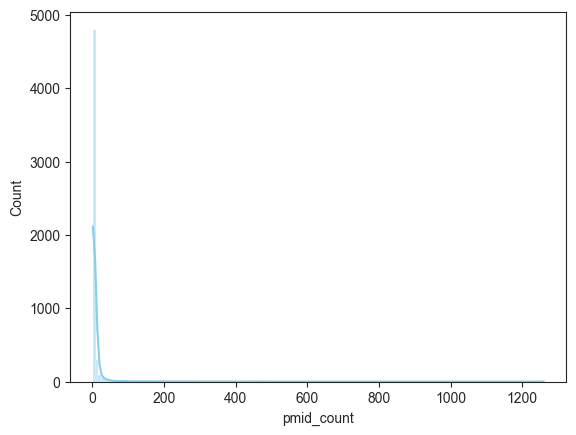

In [29]:
subs = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO', 'HP'), na=False)][['targetId', 'diseaseId', 'probeId', 'pmid']]
#print(subs.head())

# 1. Aggregate data
grouped_data = subs.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', pd.Series.nunique),
    probeId_count=('probeId', pd.Series.nunique)
).reset_index()
display(grouped_data.sort_values(by='probeId_count',ascending=False).head())

sns.histplot(data=grouped_data, x='pmid_count', kde=True, color="skyblue", bins=160)

In [30]:
interesting = gr[gr.pmid>500]
display(interesting.sort_values(by='pmid'))

,targetId,diseaseId,pmid
5548,ENSG00000146648,EFO_0000616,528
5549,ENSG00000135446,EFO_0000616,600
5550,ENSG00000171791,EFO_0000095,735
5551,ENSG00000171094,EFO_0003060,804
5552,ENSG00000171791,EFO_0000222,807
5553,ENSG00000198793,MONDO_0004992,825
5554,ENSG00000198793,EFO_0000616,978
5555,ENSG00000146648,EFO_0003060,1260


### NUMBERS

In [31]:
display(ner_triplets_ptpairs.columns)
# plotting eevidence general
dfcounts = ner_triplets_ptpairs.copy()

# Combine 'TARGET' and 'DISEASE' columns into 'TARGET-DISEASE'
dfcounts['target-disease'] = dfcounts['targetId'] + '-' + dfcounts['diseaseId']

Index(['diseaseId', 'targetId', 'datasourceId', 'allcurationYears',
       'allpublicationYears', 'allstudyYears', 'datatypeId', 'score',
       'evidenceCount', 'pmid', 'date', 'section', 'probeId', 'sentence',
       'setId', 'uniprot', 'probe', 'set', 'inchiKey', 'gene', 'control',
       'prefName', 'probeSyn', 'targetSyn', 'maxPhase', 'target-disease',
       'targetName', 'diseaseName'],
      dtype='object')

### Most frequent chemical probes

In [32]:
first_probes = dfcounts.groupby('probeId')['probe'].first().reset_index()
# Count unique PMIDs per probeId
unique_pmids = dfcounts.groupby('probeId')['pmid'].nunique().reset_index(name='pmids')
# Merge the results
result_df = pd.merge(unique_pmids, first_probes, on='probeId')
#display(result_df.sort_values(by=['pmids'], ascending=False))

### Most frequent diseases

In [33]:
print(ner_triplets_ptpairs.diseaseId.nunique())
result_df = dfcounts.groupby('diseaseId')['pmid'].nunique().reset_index(name='pmids')
dis_freq = result_df.sort_values(by=['pmids'], ascending=False).head(32).diseaseId.tolist()
print(ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.isin(dis_freq)][['diseaseId', 'diseaseName']].drop_duplicates())


1353
            diseaseId                                   diseaseName
43        EFO_0000095                  chronic lymphocytic leukemia
706       EFO_0000181         head and neck squamous cell carcinoma
1585      EFO_0000182                      hepatocellular carcinoma
2522      EFO_0000220                  acute lymphoblastic leukemia
2956      EFO_0000222                        acute myeloid leukemia
9913      EFO_0000339                  chronic myelogenous leukemia
10559     EFO_0000403                 diffuse large b-cell lymphoma
11593     EFO_0000519                       glioblastoma multiforme
11674     EFO_0000544                                     infection
12022     EFO_0000616                                      neoplasm
28817     EFO_0000621                                 neuroblastoma
28994     EFO_0000676                                     psoriasis
29133     EFO_0000702                     small cell lung carcinoma
29484     EFO_0000756                      

### Most frequent targets

In [34]:
print(ner_triplets_ptpairs.targetId.nunique())
result_tdf = dfcounts.groupby('targetId')['pmid'].nunique().reset_index(name='pmids')
tar_freq = result_tdf.sort_values(by=['pmids'], ascending=False).head(30).targetId.tolist()
print(ner_triplets_ptpairs[ner_triplets_ptpairs.targetId.isin(tar_freq)][['targetId', 'targetName']].drop_duplicates())

161
              targetId targetName
0      ENSG00000121879     PIK3CA
45     ENSG00000105810       CDK6
85     ENSG00000135446       CDK4
100    ENSG00000140443      IGF1R
364    ENSG00000171608     PIK3CD
678    ENSG00000066468      FGFR2
680    ENSG00000141736      ERBB2
683    ENSG00000198400      NTRK1
686    ENSG00000198793       MTOR
728    ENSG00000094631      HDAC6
730    ENSG00000105976        MET
758    ENSG00000106462       EZH2
1541   ENSG00000169032     MAP2K1
1549   ENSG00000171791       BCL2
1564   ENSG00000178999      AURKB
1585   ENSG00000077782      FGFR1
1615   ENSG00000096968       JAK2
2047   ENSG00000143799      PARP1
2127   ENSG00000169398       PTK2
2271   ENSG00000171552     BCL2L1
2286   ENSG00000182578      CSF1R
2340   ENSG00000171094        ALK
2348   ENSG00000146648       EGFR
2359   ENSG00000135679       MDM2
2550   ENSG00000105639       JAK3
2730   ENSG00000122025       FLT3
2758   ENSG00000162434       JAK1
11654  ENSG00000105397       TYK2
28911  ENS

### Max phase of chemical probes


In [35]:
#Getting clinical phase for probes
chembl = ChemblDB('/Users/adasme/Documents/codes/chembl_35/chembl_35_sqlite/chembl_35.db')
ner_triplets_ptpairs['maxPhase'] = ner_triplets_ptpairs.probeId.map(lambda x: chembl.get_max_phase(x)[0]).astype('Int64').replace({np.nan: None})
ner_triplets_ptpairs.groupby('maxPhase')['probeId'].nunique()


maxPhase
1    27
2    39
3    11
4    34
Name: probeId, dtype: int64

In [36]:
# Non drugs probes
drugprobes = ner_triplets_ptpairs[~ner_triplets_ptpairs.maxPhase.isnull()]
nondrugs = ner_triplets_ptpairs[ner_triplets_ptpairs.maxPhase.isnull()]
print(drugprobes.probeId.nunique())
print(nondrugs.probeId.nunique())
print(len(drugprobes[['targetId', 'diseaseId']].drop_duplicates()))
print(len(nondrugs[['targetId', 'diseaseId']].drop_duplicates()))

111
83
4853
845


### Heatmap Full version

,targetId,diseaseId,pmid_count,probeId_count
1261,ENSG00000106462,EFO_0000616,247,5
1254,ENSG00000106462,EFO_0000403,100,5
1912,ENSG00000129484,MONDO_0004992,32,5
1901,ENSG00000129484,EFO_0000616,22,5
1362,ENSG00000106462,MONDO_0004992,123,5


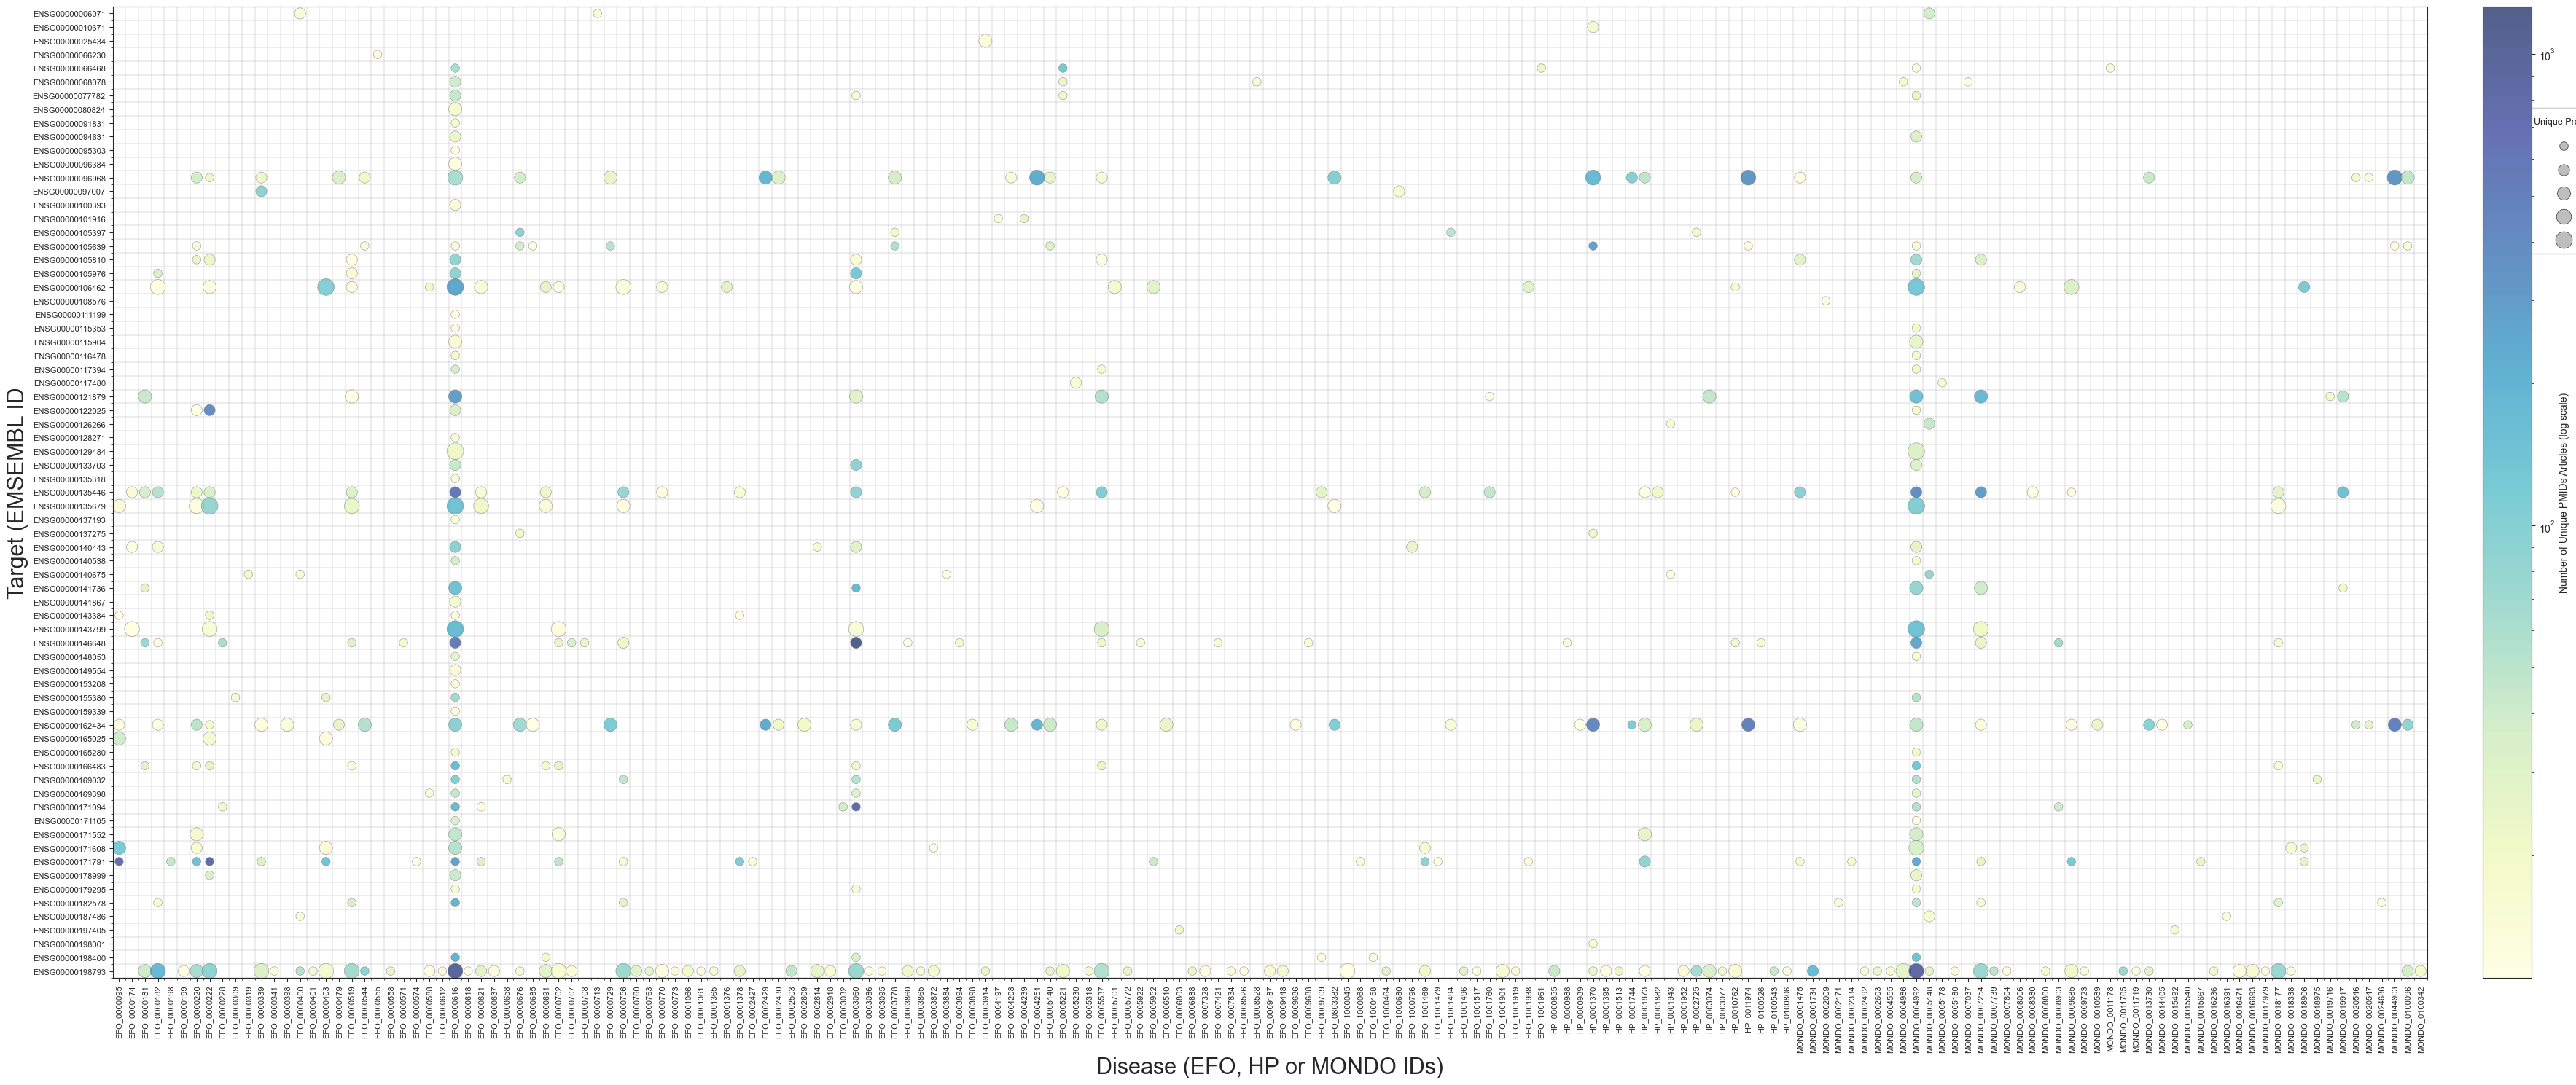

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np # Import numpy for potential calculations
# Need FixedLocator for minor ticks
from matplotlib.ticker import FixedLocator


subs = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO', 'HP'), na=False)][['targetId', 'diseaseId', 'probeId', 'pmid']]
#print(subs.head())

# 1. Aggregate data
grouped_data = subs.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', pd.Series.nunique),
    probeId_count=('probeId', pd.Series.nunique)
).reset_index()
display(grouped_data.sort_values(by='probeId_count',ascending=False).head())

grouped_data = grouped_data[grouped_data.pmid_count>10]

if grouped_data.empty:
    print("No association data found to plot.")
else:
    # 2. Map IDs to numerical coordinates
    unique_targets = sorted(grouped_data['targetId'].unique())
    unique_diseases = sorted(grouped_data['diseaseId'].unique())

    target_to_int = {target: i for i, target in enumerate(unique_targets)}
    disease_to_int = {disease: i for i, disease in enumerate(unique_diseases)}

    grouped_data['target_int'] = grouped_data['targetId'].map(target_to_int)
    grouped_data['disease_int'] = grouped_data['diseaseId'].map(disease_to_int)

    # 3. Prepare data for scatter plot 
    x_coords = grouped_data['disease_int'] # Bubbles centered at integers (0, 1, ...)
    y_coords = grouped_data['target_int'] # Bubbles centered at integers (0, 1, ...)
    bubble_sizes_raw = grouped_data['probeId_count']
    bubble_colors = grouped_data['pmid_count']

    # Bubble Size Scaling
    min_size = 20
    scale_factor = 250
    scaled_sizes = min_size + (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor if bubble_sizes_raw.max() > 0 else min_size

    # Figure Size 
    fig_width = max(40, len(unique_diseases) * 0.15)
    fig_height = max(15, len(unique_targets) * 0.15)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Color normalization (same as before)
    min_color_val = bubble_colors[bubble_colors > 0].min() if (bubble_colors > 0).any() else 1
    norm = LogNorm(vmin=min_color_val, vmax=bubble_colors.max()) if bubble_colors.max() > 0 else None

    # 6. Create the scatter plot (remove zorder)
    scatter = ax.scatter(
        x=x_coords,
        y=y_coords,
        s=scaled_sizes,
        c=bubble_colors,
        cmap='YlGnBu',
        norm=norm,
        alpha=0.7,
        edgecolors='grey',
        linewidth=0.5
        # No zorder needed here
    )



    # Set MAJOR ticks at integer positions (where labels should appear)
    ax.set_xticks(np.arange(len(unique_diseases)))
    ax.set_xticklabels(unique_diseases, rotation=90, fontsize=8) # Keep labels at integers
    ax.grid(False, which='major')

    ax.set_yticks(np.arange(len(unique_targets)))
    # Apply y-label skipping if desired (using major ticks)
    max_labels_y = 50
    ytick_skip = max(1, len(unique_targets) // max_labels_y)
    ax.set_yticklabels(unique_targets[::ytick_skip], fontsize=8)
    # If showing all y-labels: ax.set_yticklabels(unique_targets, fontsize=7)
    # Make sure the corresponding ax.set_yticks reflects the skipping:
    ax.set_yticks(np.arange(len(unique_targets))[::ytick_skip]) # Only set ticks where labels are shown

    # Set MINOR ticks at the halfway points (.5 positions)
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(len(unique_diseases)) + 0.5))
    ax.yaxis.set_minor_locator(FixedLocator(np.arange(len(unique_targets)) + 0.5))

    # Draw the grid using MINOR ticks
    ax.grid(True, which='minor', linestyle='-', linewidth=0.3, color='darkgrey')

    # Ensure grid is drawn BEHIND scatter points ---
    ax.set_axisbelow(True)

    # Set axis limits to align with the minor grid lines
    ax.set_xlim(-0.5, len(unique_diseases) - 0.5)
    ax.set_ylim(-0.5, len(unique_targets) - 0.5)

    # Invert y-axis
    ax.invert_yaxis()

    # Labels and Title 
    ax.set_xlabel('Disease (EFO, HP or MONDO IDs)', fontsize=22)
    ax.set_ylabel('Target (EMSEMBL ID', fontsize=22)

    # Color Bar 
    cbar = fig.colorbar(scatter, ax=ax, label='Number of Unique PMIDs Articles (log scale)', pad=0.02)

    # Get unique positive probe counts from the actual data
    # bubble_sizes_raw is grouped_data['probeId_count']
    unique_positive_counts = np.unique(bubble_sizes_raw[bubble_sizes_raw > 0].astype(int))

    if len(unique_positive_counts) == 0:
        legend_probe_counts = np.array([])  # No data for legend
    elif len(unique_positive_counts) <= 5:
        # If 5 or fewer unique positive counts, use all of them for the legend
        legend_probe_counts = unique_positive_counts
    else:
        # If more than 5 unique positive counts, pick up to 5 representative values using linspace
        min_val = unique_positive_counts.min()
        max_val = unique_positive_counts.max()
        # Generate 5 values, including min and max, then ensure they are unique integers
        legend_probe_counts = np.unique(np.linspace(min_val, max_val, num=5).astype(int))

    legend_handles = []
    legend_labels = []

    # Determine the overall maximum raw size for consistent scaling in the legend
    # This should match how 'scaled_sizes' for the main plot was determined
    max_raw_overall_for_scaling = bubble_sizes_raw.max() if not bubble_sizes_raw.empty and bubble_sizes_raw.max() > 0 else 0

    if len(legend_probe_counts) > 0:
        for count_val in legend_probe_counts:
            # Apply the same scaling logic as used for the main plot's bubbles:
            # scaled_sizes = min_size + (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor if bubble_sizes_raw.max() > 0 else min_size
            if max_raw_overall_for_scaling > 0:
                scaled_size_legend = min_size + (count_val / max_raw_overall_for_scaling) * scale_factor
            else:
                # Fallback if no positive max_raw_overall (e.g. all counts are 0 or data is empty)
                # This case implies all bubbles would be min_size.
                # If count_val itself can be 0 and min_size is for positive counts, adjust as needed.
                scaled_size_legend = min_size

            legend_handles.append(plt.scatter([], [], s=scaled_size_legend, c='darkgrey', alpha=0.7, edgecolors='black', linewidth=0.5))
            legend_labels.append(f'{count_val}') # Label is the raw probeId_count

        if legend_handles: # Ensure there's something to add to the legend
            size_legend = ax.legend(
                handles=legend_handles, labels=legend_labels, title='Unique Probe IDs',
                loc='upper left', bbox_to_anchor=(1.04, 0.9), # Your existing legend position
                labelspacing=2.0, borderpad=1.2, frameon=True, fontsize=8, title_fontsize=9 # Your existing legend styling
            )
            ax.add_artist(size_legend) # Add this legend to the plot

    # Layout adjustment
    plt.tight_layout()#rect=[0.03, 0.10, 0.90, 0.95])
    plt.savefig("figs/supp_ner_probes_heatmap.png", dpi=400)
    plt.savefig("figs/supp_ner_probes_heatmap.svg", dpi=400)
    plt.show()


### Heatmap zoom in to most common targets/diseases pairs

,diseaseId,diseaseName
0,EFO_0000181,head and neck squamous cell carcinoma
1,EFO_0000182,hepatocellular carcinoma
2,EFO_0000220,acute lymphoblastic leukemia
3,EFO_0000616,neoplasm
4,EFO_0003060,non-small cell lung carcinoma
5,EFO_0005221,cholangiocarcinoma
6,EFO_0005537,triple-negative breast cancer
7,MONDO_0004992,cancer
8,MONDO_0007254,breast cancer
12,EFO_0000222,acute myeloid leukemia


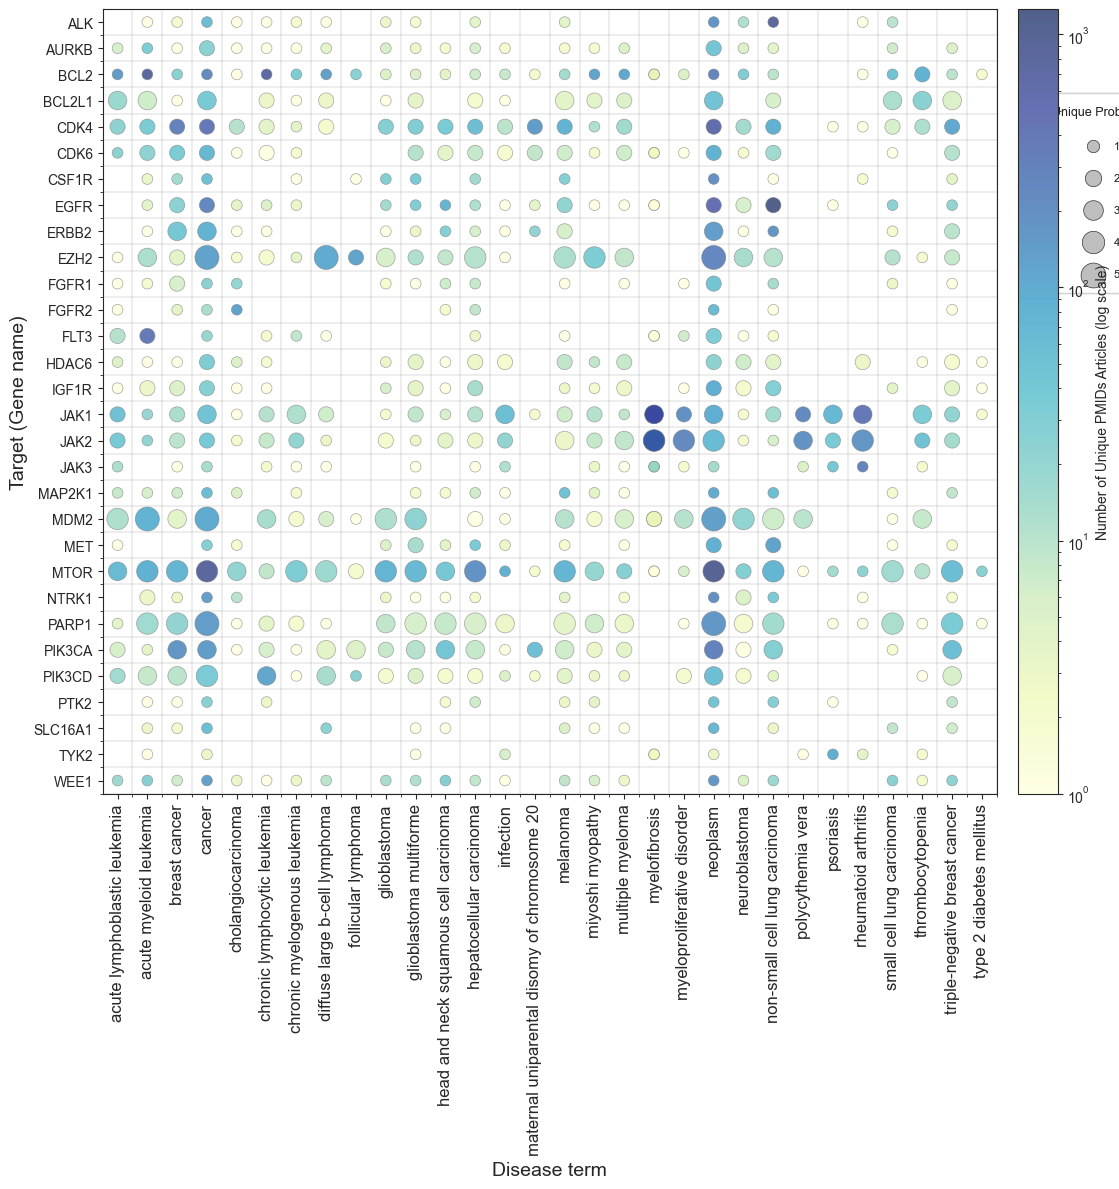

In [38]:
subs = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO', 'HP'), na=False)]

# 1. Create small, unique mapping tables
disease_map = subs[['diseaseId', 'diseaseName']].drop_duplicates()
target_map = subs[['targetId', 'targetName']].drop_duplicates()

# 2. Aggregate data using only the necessary columns
grouped_data = subs.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', 'nunique'),
    probeId_count=('probeId', 'nunique')
).reset_index()

# 3. Filter aggregated data to include mopst frequent targets and most frequent diseases
grouped_data = grouped_data[
    (grouped_data.diseaseId.isin(dis_freq)) & 
    (grouped_data.targetId.isin(tar_freq))
]

### filter for most frequent T-D pairs
#grouped_data = grouped_data[
#    (grouped_data.diseaseId.isin(sample.diseaseId.unique().tolist())) & 
#    (grouped_data.targetId.isin(sample.targetId.unique().tolist()))
#]

# 4. Merge with the small, efficient mapping tables
grouped_data = grouped_data.merge(disease_map, on='diseaseId', how='left')
grouped_data = grouped_data.merge(target_map, on='targetId', how='left')

# 5. Select final columns. 
display(grouped_data[['diseaseId','diseaseName']].drop_duplicates())
grouped_data = grouped_data[['targetName', 'diseaseName', 'probeId_count', 'pmid_count']]


if grouped_data.empty:
    print("No association data found to plot.")
else:
    # 2. Map IDs to numerical coordinates
    unique_targets = sorted(grouped_data['targetName'].unique())
    unique_diseases = sorted(grouped_data['diseaseName'].unique())

    target_to_int = {target: i for i, target in enumerate(unique_targets)}
    disease_to_int = {disease: i for i, disease in enumerate(unique_diseases)}

    grouped_data['target_int'] = grouped_data['targetName'].map(target_to_int)
    grouped_data['disease_int'] = grouped_data['diseaseName'].map(disease_to_int)

    # 3. Prepare data for scatter plot 
    x_coords = grouped_data['disease_int'] # Bubbles centered at integers (0, 1, ...)
    y_coords = grouped_data['target_int'] # Bubbles centered at integers (0, 1, ...)
    bubble_sizes_raw = grouped_data['probeId_count']
    bubble_colors = grouped_data['pmid_count']

    # Bubble Size Scaling
    scale_factor = 300
    scaled_sizes = (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor

    # Figure Size 
    fig_width = 12
    fig_height = 12
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Color normalization (same as before)
    min_color_val = bubble_colors[bubble_colors > 0].min() if (bubble_colors > 0).any() else 1
    norm = LogNorm(vmin=min_color_val, vmax=bubble_colors.max()) if bubble_colors.max() > 0 else None

    # 6. Create the scatter plot (remove zorder)
    scatter = ax.scatter(
        x=x_coords,
        y=y_coords,
        s=scaled_sizes,
        c=bubble_colors,
        cmap='YlGnBu',
        norm=norm,
        alpha=0.7,
        edgecolors='grey',
        linewidth=0.5
        # No zorder needed here
    )

    # Set MAJOR ticks at integer positions (where labels should appear)
    ax.set_xticks(np.arange(len(unique_diseases)))
    ax.set_xticklabels(unique_diseases, rotation=90, fontsize=12) # Keep labels at integers
    ax.grid(False, which='major')

    ax.set_yticks(np.arange(len(unique_targets)))
    # Apply y-label skipping if desired (using major ticks)
    max_labels_y = 50
    ytick_skip = max(1, len(unique_targets) // max_labels_y)
    ax.set_yticklabels(unique_targets[::ytick_skip], fontsize=10)
    # If showing all y-labels: ax.set_yticklabels(unique_targets, fontsize=7)
    # Make sure the corresponding ax.set_yticks reflects the skipping:
    ax.set_yticks(np.arange(len(unique_targets))[::ytick_skip]) # Only set ticks where labels are shown

    # Set MINOR ticks at the halfway points (.5 positions)
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(len(unique_diseases)) + 0.5))
    ax.yaxis.set_minor_locator(FixedLocator(np.arange(len(unique_targets)) + 0.5))

    # Draw the grid using MINOR ticks
    ax.grid(True, which='minor', linestyle='-', linewidth=0.3, color='darkgrey')

    # Ensure grid is drawn BEHIND scatter points ---
    ax.set_axisbelow(True)

    # Set axis limits to align with the minor grid lines
    ax.set_xlim(-0.5, len(unique_diseases) - 0.5)
    ax.set_ylim(-0.5, len(unique_targets) - 0.5)

    # Invert y-axis
    ax.invert_yaxis()

    # Labels and Title 
    ax.set_xlabel('Disease term', fontsize=14)
    ax.set_ylabel('Target (Gene name)', fontsize=14)

    # Color Bar 
    cbar = fig.colorbar(scatter, ax=ax, label='Number of Unique PMIDs Articles (log scale)', pad=0.02)

    # Get unique positive probe counts from the actual data
    # bubble_sizes_raw is grouped_data['probeId_count']
    unique_positive_counts = np.unique(bubble_sizes_raw[bubble_sizes_raw > 0].astype(int))

    if len(unique_positive_counts) == 0:
        legend_probe_counts = np.array([])  # No data for legend
    elif len(unique_positive_counts) <= 5:
        # If 5 or fewer unique positive counts, use all of them for the legend
        legend_probe_counts = unique_positive_counts
    else:
        # If more than 5 unique positive counts, pick up to 5 representative values using linspace
        min_val = unique_positive_counts.min()
        max_val = unique_positive_counts.max()
        # Generate 5 values, including min and max, then ensure they are unique integers
        legend_probe_counts = np.unique(np.linspace(min_val, max_val, num=5).astype(int))

    legend_handles = []
    legend_labels = []

    # Determine the overall maximum raw size for consistent scaling in the legend
    # This should match how 'scaled_sizes' for the main plot was determined
    max_raw_overall_for_scaling = bubble_sizes_raw.max() if not bubble_sizes_raw.empty and bubble_sizes_raw.max() > 0 else 0

    if len(legend_probe_counts) > 0:
        for count_val in legend_probe_counts:
            # Apply the same scaling logic as used for the main plot's bubbles:
            # scaled_sizes = min_size + (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor if bubble_sizes_raw.max() > 0 else min_size
            if max_raw_overall_for_scaling > 0:
                scaled_size_legend = min_size + (count_val / max_raw_overall_for_scaling) * scale_factor
            else:
                # Fallback if no positive max_raw_overall (e.g. all counts are 0 or data is empty)
                # This case implies all bubbles would be min_size.
                # If count_val itself can be 0 and min_size is for positive counts, adjust as needed.
                scaled_size_legend = min_size

            legend_handles.append(plt.scatter([], [], s=scaled_size_legend, c='darkgrey', alpha=0.7, edgecolors='black', linewidth=0.5))
            legend_labels.append(f'{count_val}') # Label is the raw probeId_count

        if legend_handles: # Ensure there's something to add to the legend
            size_legend = ax.legend(
                handles=legend_handles, labels=legend_labels, title='Unique Probe IDs',
                loc='upper left', bbox_to_anchor=(1.04, 0.9), # Your existing legend position
                labelspacing=2.0, borderpad=1.2, frameon=True, fontsize=8, title_fontsize=9 # Your existing legend styling
            )
            ax.add_artist(size_legend) # Add this legend to the plot

    # Layout adjustment
    plt.tight_layout()#rect=[0.03, 0.10, 0.90, 0.95])
    plt.savefig("figs/ner_probes_heatmap_zoom.png", dpi=400)
    plt.savefig("figs/ner_probes_heatmap_zoom.svg", dpi=400)
    plt.show()


In [39]:
subs[(subs.diseaseId=='MONDO_0004992') & (subs.targetId == 'ENSG00000106462')].probeId.unique()

array(['CHEMBL3414621', 'CHEMBL2204995', 'CHEMBL4297463', 'CHEMBL3360855',
       'CHEMBL3672841'], dtype=object)

In [40]:
ner_triplets_ptpairs.maxPhase.unique()

array([4, None, 2, 3, 1], dtype=object)

### OT evidence for target-diseases found

5556


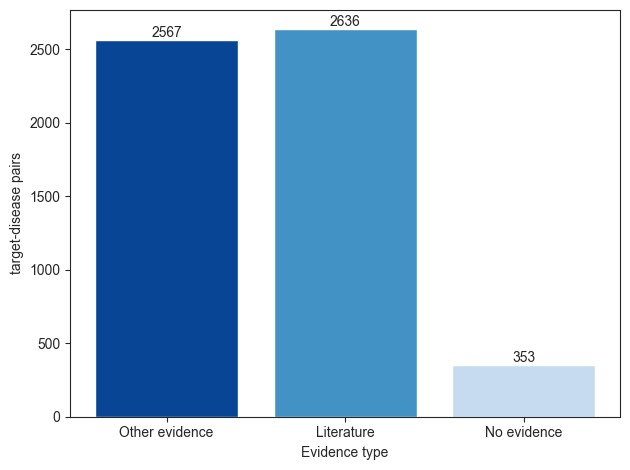

In [41]:
# plotting eevidence general
df2 = ner_triplets_ptpairs.copy()

# Combine 'TARGET' and 'DISEASE' columns into 'TARGET-DISEASE'
df2['target-disease'] = df2['targetId'] + '-' + df2['diseaseId']
print(df2['target-disease'].nunique())

# Get unique target-disease pairs for each category with the specified priority
other_pairs = set(df2[~df2['datatypeId'].isnull() & (df2['datatypeId'] != 'literature')]['target-disease'].unique())
lit_pairs = set(df2[df2['datatypeId'] == 'literature']['target-disease'].unique()) - other_pairs
none_pairs = set(df2[df2['datatypeId'].isnull()]['target-disease'].unique()) - other_pairs - lit_pairs
ecounts= [len(other_pairs), len(lit_pairs), len(none_pairs)]
evidence = ['Other evidence', 'Literature', 'No evidence']

# Define the colors you want to use
colors = ['#084594', '#4292c6', '#c6dbef']

# Create the bar plot
plt.bar(evidence, ecounts, color=colors)

# Add value labels on top of each bar
for i in range(len(evidence)):
    plt.text(i, ecounts[i], ecounts[i], ha='center', va='bottom')

# Add labels and title
plt.xlabel("Evidence type")
plt.ylabel("target-disease pairs")

plt.savefig(f'figs/evidence.png', dpi=600)  # Uncomment to save figures
plt.tight_layout()

# Display the plot
plt.show()

5556


array(['literature', 'known_drug', 'affected_pathway', 'somatic_mutation',
       'genetic_association', 'rna_expression', 'animal_model', nan],
      dtype=object)

[357, 1037, 953, 81, 33, 106, 2636, 353]


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/74416979.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=values, palette='Blues_r')


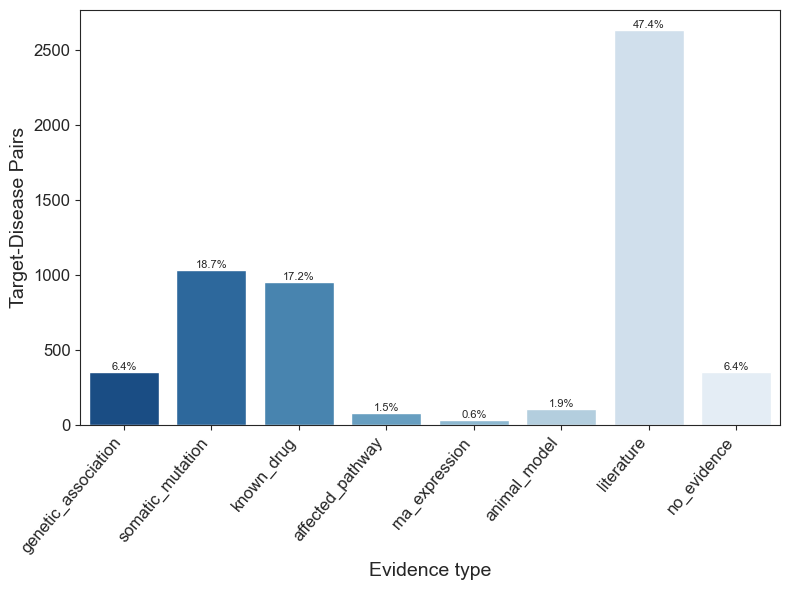

In [42]:
# plotting eevidence general
df = ner_triplets_ptpairs.copy()

# Combine 'TARGET' and 'DISEASE' columns into 'TARGET-DISEASE'
df['target-disease'] = df['targetId'] + '-' + df['diseaseId']
print(df['target-disease'].nunique())
display(df.datatypeId.unique())

ranked_categories = [
    "genetic_association",
    "somatic_mutation",
    "known_drug",
    "affected_pathway",
    "rna_expression",
    "animal_model",
    "literature",
]

counts = {}
remaining_pairs = set(df['target-disease'].unique()) # Use a set for faster removal.

for category in ranked_categories:
    category_df = df[df.datatypeId == category]
    valid_pairs = set(category_df['target-disease'].unique()) & remaining_pairs # intersection of the pairs in the category and remaining pairs.
    counts[category] = len(valid_pairs)
    remaining_pairs -= valid_pairs # Remove already counted pairs.

counts['no_evidence'] = len(remaining_pairs) # remaining pairs not in any category.

categories = list(counts.keys())
values = list(counts.values())
print(values)

# Create the barplot
plt.figure(figsize=(8, 6))
sns.barplot(x=categories, y=values, palette='Blues_r')
plt.xlabel("Evidence type", fontsize=14)
plt.ylabel("Target-Disease Pairs", fontsize=14)
plt.xticks(rotation=50, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Add value labels on top of each bar
for i in range(len(ranked_categories)+1):
    plt.text(i, values[i], f"{(values[i]*100)/sum(values):.1f}%", ha='center', va='bottom', fontsize=8)


# Set y-axis to log scale
plt.gca().set_facecolor('white')

# --- Ensure all four spines are visible to form a box ---
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig(f'figs/evidence_datatype_ranking.svg', dpi=600)  # Uncomment to save figures
plt.savefig(f'figs/evidence_datatype_ranking.png', dpi=600)  # Uncomment to save figures
plt.show()

### Evidence by max phase

In [43]:

df.groupby('maxPhase')['target-disease'].nunique()

maxPhase
1     430
2     677
3     375
4    3712
Name: target-disease, dtype: int64

/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/1581228084.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfcopy2['maxPhase'] = dfcopy2.maxPhase.fillna(int(0))


array([4, 0, 2, 3, 1])

,diseaseId,targetId,maxPhase,pmid
0,DOID_0050890,ENSG00000143799,3,1
1,DOID_0050890,ENSG00000198793,4,2
2,DOID_10718,ENSG00000110148,0,1
3,DOID_13406,ENSG00000162434,4,1
4,DOID_7551,ENSG00000066468,4,6


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/1581228084.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Preclinical', 1, 2, 3, 4], showfliers=False)


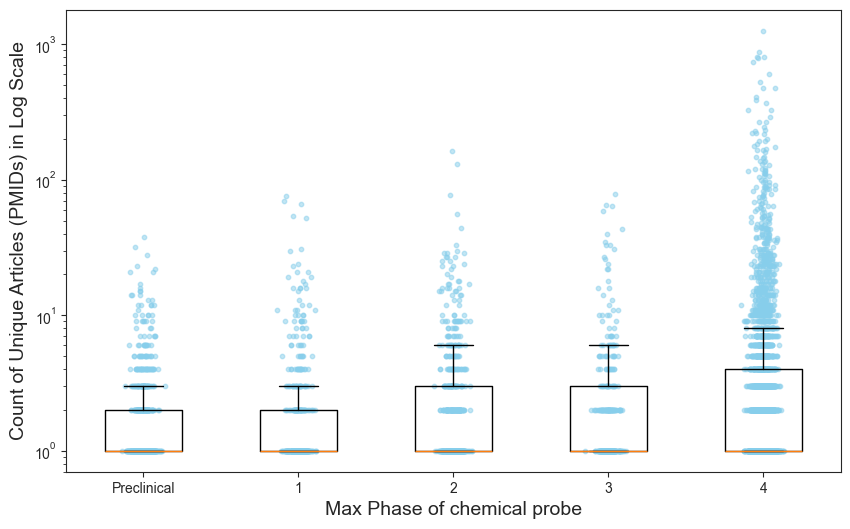

In [44]:
# Group by diseaseId, targetId, and maxphase, then count unique PMIDs
dfcopy2 = ner_triplets_ptpairs.copy()
dfcopy2['maxPhase'] = dfcopy2.maxPhase.fillna(int(0))
display(dfcopy2.maxPhase.unique())

grouped_data = dfcopy2.groupby(['diseaseId', 'targetId', 'maxPhase'])['pmid'].nunique().reset_index()
grouped_data['maxPhase'] = pd.Categorical(grouped_data['maxPhase'], categories=[0, 1,2,3,4], ordered=True)

display(grouped_data.head())

# Create a list to store PMID counts for each maxphase
data_to_plot = []
max_phases = [0, 1, 2, 3, 4]
for phase in max_phases:
    data_to_plot.append(grouped_data[grouped_data['maxPhase'] == phase]['pmid'].values)

#display(data_to_plot)

# Create the boxplot
plt.figure(figsize=(10, 6)) 
plt.boxplot(data_to_plot, labels=['Preclinical', 1, 2, 3, 4], showfliers=False)
#plt.title('Distribution of Unique PMID Counts by Maxphase (Log Scale)')
plt.xlabel("Max Phase of chemical probe", fontsize=14)
plt.ylabel('Count of Unique Articles (PMIDs) in Log Scale', fontsize=14)

# Add scatter plot points
for i, phase in enumerate(grouped_data['maxPhase'].unique()):
    x = np.random.normal(i + 1, 0.04, size=len(data_to_plot[i]))  # Add jitter
    plt.scatter(x, data_to_plot[i], alpha=0.5, s=10, color='skyblue')  # Adjust alpha and size as needed




# Set y-axis to log scale
plt.yscale('log')

# MAke background white
plt.gca().set_facecolor('white')

# --- Ensure all four spines are visible to form a box ---
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.savefig(f'figs/evidence_maxphase_scatter.svg', dpi=600)  # Uncomment to save figures
plt.savefig(f'figs/evidence_maxphase_scatter.png', dpi=600)  # Uncomment to save figures
plt.show()

##### Finding specific cases to discuss

In [45]:
### cases
maincopy = ner_triplets_ptpairs.copy()
maincopy['target-disease'] = maincopy['targetId'] + '-' + maincopy['diseaseId']
maincopy['maxPhase'] = maincopy.maxPhase.fillna('NA')

In [46]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None) 

In [47]:

subset = maincopy[(maincopy.datatypeId.isnull()) & (maincopy.maxPhase == 'NA')]
subset.columns
subset[['target-disease','probeId', 'probe']].drop_duplicates()

,target-disease,probeId,probe
56791,ENSG00000117480-EFO_0007948,CHEMBL1651524,PF-3845
106485,ENSG00000115904-EFO_0004142,CHEMBL4519023,BI-3406
110864,ENSG00000165025-EFO_0009482,CHEMBL2177736,PRT062607
112948,ENSG00000132964-HP_0010762,CHEMBL3408213,CCT251545
113482,ENSG00000131408-MONDO_0001336,CHEMBL62136,TO-901317
113485,ENSG00000131408-MONDO_0001336,CHEMBL59030,GW-3965
114165,ENSG00000159339-MONDO_0002046,CHEMBL4539512,GSK484
185576,ENSG00000164128-EFO_1001375,CHEMBL1774204,BIBO3304
198028,ENSG00000112062-MONDO_0007915,CHEMBL2152944,skepinone-L
247776,ENSG00000117480-HP_0001347,CHEMBL1651524,PF-3845


In [ ]:
#clinical-stage molecules, generating evidence that complements primary indication-focused data
maincopy[maincopy['target-disease'] == 'ENSG00000178999-MONDO_0005178'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'gene']]

,pmid,date,sentence,probeId,targetId,diseaseId,gene
784756,37634474,2023-08-25,Barasertib impedes chondrocyte senescence and alleviates osteoarthritis by mitigating the destabilization of heterochromatin induced by AURKB.,CHEMBL415049,ENSG00000178999,MONDO_0005178,AURKB
784757,37634474,2023-08-25,Barasertib impedes chondrocyte senescence and alleviates osteoarthritis by mitigating the destabilization of heterochromatin induced by AURKB.,CHEMBL415049,ENSG00000178999,MONDO_0005178,AURKB
784758,37634474,2023-08-25,Barasertib impedes chondrocyte senescence and alleviates osteoarthritis by mitigating the destabilization of heterochromatin induced by AURKB.,CHEMBL415049,ENSG00000178999,MONDO_0005178,AURKB


In [49]:
#Reporting the risk of diseas einduced by drug
maincopy[maincopy['target-disease'] == 'ENSG00000126266-HP_0002904'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'gene']]

,pmid,date,sentence,probeId,targetId,diseaseId,gene
705881,32796590,2020-08-01,"Of note, only the IC50 values but no other predictor indicated hyperbilirubinemia risk for fasiglifam, an investigational G protein-coupled receptor 40 agonist terminated late in phase III due to liver safety concerns [81].",CHEMBL1829174,ENSG00000126266,HP_0002904,FFAR1
705882,32796590,2020-08-01,"Of note, only the IC50 values but no other predictor indicated hyperbilirubinemia risk for fasiglifam, an investigational G protein-coupled receptor 40 agonist terminated late in phase III due to liver safety concerns [81].",CHEMBL1829174,ENSG00000126266,HP_0002904,FFAR1
705883,32796590,2020-08-01,"Of note, only the IC50 values but no other predictor indicated hyperbilirubinemia risk for fasiglifam, an investigational G protein-coupled receptor 40 agonist terminated late in phase III due to liver safety concerns [81].",CHEMBL1829174,ENSG00000126266,HP_0002904,FFAR1
705884,32796590,2020-08-01,"Of note, only the IC50 values but no other predictor indicated hyperbilirubinemia risk for fasiglifam, an investigational G protein-coupled receptor 40 agonist terminated late in phase III due to liver safety concerns [81].",CHEMBL1829174,ENSG00000126266,HP_0002904,FFAR1


In [50]:
# Referencing to clinical trials
maincopy[maincopy['target-disease'] == 'ENSG00000106462-MONDO_0012825'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'gene']]
#maincopy[maincopy['pmid'] == '32967265'][['PMID','date','sentence', 'PROBE', 'TARGET', 'DISEASES']]

,pmid,date,sentence,probeId,targetId,diseaseId,gene
820291,32967265,2020-09-01,"Among new epigenetic therapies, tazemetostat, an enhancer of zeste homologue 2 (EZH2) inhibitor, recently approved by the US Food and Drug Administration (FDA) for the treatment of advanced epithelioid sarcoma, has also been tried in integrase interactor 1 (INI-1) negative EMC cases [69] within a phase I–II basket trial of INI-1-negative solid tumors (NCT02601937, NCT02601950), with pending results.",CHEMBL3414621,ENSG00000106462,MONDO_0012825,EZH2
820292,32967265,2020-09-01,"Among new epigenetic therapies, tazemetostat, an enhancer of zeste homologue 2 (EZH2) inhibitor, recently approved by the US Food and Drug Administration (FDA) for the treatment of advanced epithelioid sarcoma, has also been tried in integrase interactor 1 (INI-1) negative EMC cases [69] within a phase I–II basket trial of INI-1-negative solid tumors (NCT02601937, NCT02601950), with pending results.",CHEMBL3414621,ENSG00000106462,MONDO_0012825,EZH2
820293,37213274,2023-01-01,"Also, interim results from a phase I study of the EZH2 inhibitor tazemetostat in relapsed or refractory INI1-negative tumors (e.g., epithelioid sarcoma, extraskeletal myxoid chondrosarcoma, dedifferentiated chordoma) or synovial sarcoma showed promising anti-tumor activity (NCT02601937) (Table 2).",CHEMBL3414621,ENSG00000106462,MONDO_0012825,EZH2
820294,37213274,2023-01-01,"Also, interim results from a phase I study of the EZH2 inhibitor tazemetostat in relapsed or refractory INI1-negative tumors (e.g., epithelioid sarcoma, extraskeletal myxoid chondrosarcoma, dedifferentiated chordoma) or synovial sarcoma showed promising anti-tumor activity (NCT02601937) (Table 2).",CHEMBL3414621,ENSG00000106462,MONDO_0012825,EZH2


In [51]:
# No evidence and no clinical trials
maincopy[maincopy['target-disease'] == 'ENSG00000131408-HP_0000855'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'probe', 'gene']].drop_duplicates()


,pmid,date,sentence,probeId,targetId,diseaseId,probe,gene
503706,33877366,2021-07-01,"While LXR agonists may cause hepatic fat accumulation, LXR inverse agonists have the ability to suppress the expression of the lipogenic LXR target genes Fasn and Srepb1. Several compounds that bind to both LXRα and LXRβ (LXR agonists) have been developed [48–55] (Table 3) and studied for the treatment of NAFLD and atherosclerosis, as they have been shown to reduce lipogenesis, inflammation, insulin resistance and hyperlipidaemia, but some like T0901317 and GW3965 are associated to increased hepatic fat accumulation [53, 54].",CHEMBL62136,ENSG00000131408,HP_0000855,TO-901317,NR1H2
503709,18796617,2008-12-01,"When a pharmacological approach was used to ameliorate IL-6–induced insulin resistance, only the synthetic LXR agonists GW3965 and T0901317 completely restored insulin-stimulated glucose uptake, an effect that was not produced by peroxisome proliferator–activated receptor (PPAR) δ agonist, although both PPARδ and LXRβ are expressed in skeletal muscle (26,47).",CHEMBL62136,ENSG00000131408,HP_0000855,TO-901317,NR1H2
503710,18796617,2008-12-01,"When a pharmacological approach was used to ameliorate IL-6–induced insulin resistance, only the synthetic LXR agonists GW3965 and T0901317 completely restored insulin-stimulated glucose uptake, an effect that was not produced by peroxisome proliferator–activated receptor (PPAR) δ agonist, although both PPARδ and LXRβ are expressed in skeletal muscle (26,47).",CHEMBL59030,ENSG00000131408,HP_0000855,GW-3965,NR1H2
503712,33877366,2021-07-01,"While LXR agonists may cause hepatic fat accumulation, LXR inverse agonists have the ability to suppress the expression of the lipogenic LXR target genes Fasn and Srepb1. Several compounds that bind to both LXRα and LXRβ (LXR agonists) have been developed [48–55] (Table 3) and studied for the treatment of NAFLD and atherosclerosis, as they have been shown to reduce lipogenesis, inflammation, insulin resistance and hyperlipidaemia, but some like T0901317 and GW3965 are associated to increased hepatic fat accumulation [53, 54].",CHEMBL59030,ENSG00000131408,HP_0000855,GW-3965,NR1H2


## Probes articles with dated evidence


In [52]:
print(len(ner_triplets_ptpairs[['diseaseId', 'targetId']].drop_duplicates()))
ner_triplets_ptpairs['target-disease'] = ner_triplets_ptpairs['targetId'] + '-' + ner_triplets_ptpairs['diseaseId']

5556


In [53]:
evidence_dated = ner_triplets_ptpairs[ner_triplets_ptpairs[['allcurationYears','allpublicationYears','allstudyYears']].notnull().any(axis=1)]
print(len(evidence_dated[['diseaseId', 'targetId']].drop_duplicates()))

4558


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/133113521.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


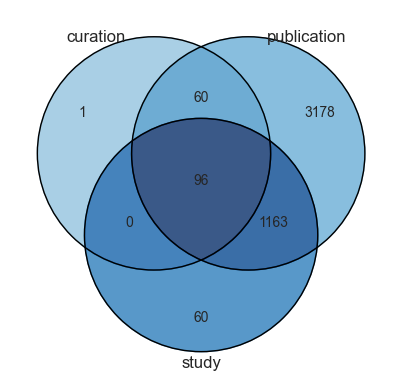

In [54]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import Counter


sets = {
    'curation': set(ner_triplets_ptpairs[ner_triplets_ptpairs.allcurationYears.notnull()]['target-disease'].drop_duplicates()),
    'publication': set(ner_triplets_ptpairs[ner_triplets_ptpairs.allpublicationYears.notnull()]['target-disease'].drop_duplicates()),
    'study': set(ner_triplets_ptpairs[ner_triplets_ptpairs.allstudyYears.notnull()]['target-disease'].drop_duplicates())
}

set_labels = list(sets.keys())
sets = list(sets.values())

# Create the Venn diagram (unweighted)
v = venn3(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    set_labels=set_labels,
)

# Remove the default labels
for text in v.set_labels:
    text.set_text('')

# Get the positions of the labels
label_positions = [text.get_position() for text in v.set_labels]

# Manually set the labels to the correct position and adjust size
for i, label in enumerate(set_labels):
    plt.text(label_positions[i][0], label_positions[i][1], label, ha='center', va='center', fontsize=12)

# Draw circles with fixed radius for unweighted appearance
circles = venn3_circles(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    linestyle="solid",
    linewidth=1,
)

# --- Color Handling with Blues Colormap ---
# Get the Blues colormap
cmap = cm.get_cmap("Blues")

# Define colors from the colormap for each region
# You can adjust these values (0.3 - 0.9) for different shades
colors = [
    cmap(0.4),  # A only
    cmap(0.5),  # B only
    cmap(0.6),  # A and B
    cmap(0.7),  # C only
    cmap(0.8),  # A and C
    cmap(0.9),  # B and C
    cmap(1.0),  # A, B, and C
]

# Set colors for each region
for i, color in enumerate(colors):
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_color(color)
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_alpha(0.8) # Add some alpha for visibility

# Set the labels for each region (manually calculate intersections)
v.get_label_by_id("100").set_text(len(sets[0] - sets[1] - sets[2]))  # A only
v.get_label_by_id("010").set_text(len(sets[1] - sets[0] - sets[2]))  # B only
v.get_label_by_id("110").set_text(
    len(sets[0] & sets[1] - sets[2])
)  # A and B
v.get_label_by_id("001").set_text(len(sets[2] - sets[0] - sets[1]))  # C only
v.get_label_by_id("101").set_text(
    len(sets[0] & sets[2] - sets[1])
)  # A and C
v.get_label_by_id("011").set_text(
    len(sets[1] & sets[2] - sets[0])
)  # B and C
v.get_label_by_id("111").set_text(
    len(sets[0] & sets[1] & sets[2])
)  # A, B, and C

plt.savefig(f'figs/supp_dated_evidence.png', dpi=600)  # Uncomment to save figures

# Display the diagram
plt.show()

In [55]:
evidence_dated = ner_triplets_ptpairs[ner_triplets_ptpairs[['allcurationYears','allstudyYears', 'allpublicationYears']].notnull().any(axis=1)]
print(evidence_dated['target-disease'].nunique())

4558


In [56]:
ner_triplets_ptpairs_nl = ner_triplets_ptpairs[ner_triplets_ptpairs.datatypeId != 'literature']
evidence_dated_nl = ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl[['allcurationYears','allstudyYears', 'allpublicationYears']].notnull().any(axis=1)]
print(evidence_dated_nl['target-disease'].nunique())

1688


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_1548/419693587.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


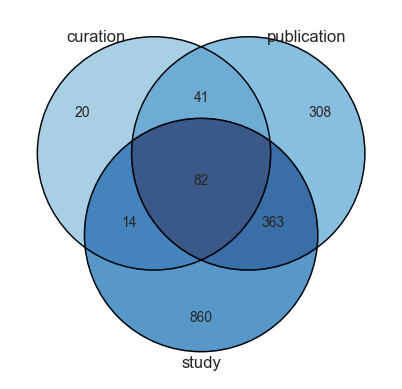

In [57]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import Counter


sets = {
    'curation': set(ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl.allcurationYears.notnull()]['target-disease'].drop_duplicates()),
    'publication': set(ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl.allpublicationYears.notnull()]['target-disease'].drop_duplicates()),
    'study': set(ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl.allstudyYears.notnull()]['target-disease'].drop_duplicates())
}

set_labels = list(sets.keys())
sets = list(sets.values())

# Create the Venn diagram (unweighted)
v = venn3(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    set_labels=set_labels,
)

# Remove the default labels
for text in v.set_labels:
    text.set_text('')

# Get the positions of the labels
label_positions = [text.get_position() for text in v.set_labels]

# Manually set the labels to the correct position and adjust size
for i, label in enumerate(set_labels):
    plt.text(label_positions[i][0], label_positions[i][1], label, ha='center', va='center', fontsize=12)

# Draw circles with fixed radius for unweighted appearance
circles = venn3_circles(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    linestyle="solid",
    linewidth=1,
)

# --- Color Handling with Blues Colormap ---
# Get the Blues colormap
cmap = cm.get_cmap("Blues")

# Define colors from the colormap for each region
# You can adjust these values (0.3 - 0.9) for different shades
colors = [
    cmap(0.4),  # A only
    cmap(0.5),  # B only
    cmap(0.6),  # A and B
    cmap(0.7),  # C only
    cmap(0.8),  # A and C
    cmap(0.9),  # B and C
    cmap(1.0),  # A, B, and C
]

# Set colors for each region
for i, color in enumerate(colors):
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_color(color)
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_alpha(0.8) # Add some alpha for visibility

# Set the labels for each region (manually calculate intersections)
v.get_label_by_id("100").set_text(len(sets[0] - sets[1] - sets[2]))  # A only
v.get_label_by_id("010").set_text(len(sets[1] - sets[0] - sets[2]))  # B only
v.get_label_by_id("110").set_text(
    len(sets[0] & sets[1] - sets[2])
)  # A and B
v.get_label_by_id("001").set_text(len(sets[2] - sets[0] - sets[1]))  # C only
v.get_label_by_id("101").set_text(
    len(sets[0] & sets[2] - sets[1])
)  # A and C
v.get_label_by_id("011").set_text(
    len(sets[1] & sets[2] - sets[0])
)  # B and C
v.get_label_by_id("111").set_text(
    len(sets[0] & sets[1] & sets[2])
)  # A, B, and C

plt.savefig(f'figs/supp_dated_evidence.png', dpi=600)  # Uncomment to save figures

# Display the diagram
plt.show()

In [58]:
## Find all cases where the probe article was published before the earliest evience in OT
## Find cases where many articles and many probes were found before the evidence
#Only then make the line plot for such cases (no more than 10 good cases)
#should we check the section where sentence was found?

In [59]:
def min_first_evidence(group):
  """Calculates the minimum firstEvidence, excluding 'literature' datatype."""
  eligible_rows = group[group['datatypeId'] != 'literature']
  if eligible_rows.empty:
    return 0  # Return 0 if no eligible rows
  else:
    return eligible_rows['firstEvidence'].min()

In [60]:
# Calculting difference in years
evidence_dated_nl['date'] = pd.to_datetime(evidence_dated_nl['date'])

evidence_dated_nl['firstEvidence_study'] = evidence_dated_nl['allstudyYears'].apply(lambda x: min(int(year) for year in x[1:-1].split(', ')) if pd.notnull(x) and x[1:-1].strip() else None)
evidence_dated_nl['firstEvidence_curation'] = evidence_dated_nl['allcurationYears'].apply(lambda x: min(int(year) for year in x[1:-1].split(', ')) if pd.notnull(x) and x[1:-1].strip() else None)
evidence_dated_nl['firstEvidence_pub'] = evidence_dated_nl['allpublicationYears'].apply(lambda x: min(int(year) for year in x[1:-1].split(', ')) if pd.notnull(x) and x[1:-1].strip() else None)

evidence_dated_nl['firstEvidence'] = evidence_dated_nl[['firstEvidence_study', 'firstEvidence_curation', 'firstEvidence_pub']].min(axis=1)
evidence_dated_nl['firstEvidence'] = pd.to_numeric(evidence_dated_nl['firstEvidence'], errors='coerce').fillna(0).astype(int)
#display(evidence_dated)


# Calculate the minimum firstEvidence for each group
#min_evidence = evidence_dated.groupby(['diseaseId', 'targetId']).apply(min_first_evidence)

# Merge the minimum firstEvidence back into the original DataFrame
#evidence_dated_all = evidence_dated.merge(min_evidence.rename('firstEvidenceAll'), left_on=['diseaseId', 'targetId'], right_index=True)
evidence_dated_nl['firstEvidenceAll'] = evidence_dated_nl.groupby(['targetId', 'diseaseId'])['firstEvidence'].transform('min')



In [61]:
evidence_dated_nl.columns

Index(['diseaseId', 'targetId', 'datasourceId', 'allcurationYears',
       'allpublicationYears', 'allstudyYears', 'datatypeId', 'score',
       'evidenceCount', 'pmid', 'date', 'section', 'probeId', 'sentence',
       'setId', 'uniprot', 'probe', 'set', 'inchiKey', 'gene', 'control',
       'prefName', 'probeSyn', 'targetSyn', 'maxPhase', 'target-disease',
       'targetName', 'diseaseName', 'firstEvidence_study',
       'firstEvidence_curation', 'firstEvidence_pub', 'firstEvidence',
       'firstEvidenceAll'],
      dtype='object')

In [62]:
#Only cases where probes evidence was before other evidence
subset = evidence_dated_nl[evidence_dated_nl.date.dt.year.astype(int) < evidence_dated_nl.firstEvidenceAll.astype(int)][[ 'pmid', 'date', 'targetId', 'diseaseId', 'probeId', 'gene', 'probe', 'diseaseName', 'inchiKey', 'sentence', 'datasourceId', 'datatypeId', 'firstEvidence', 'firstEvidenceAll']] #, 
display(len(subset[['diseaseId', 'targetId']].drop_duplicates()))
display(len(subset[['diseaseId', 'targetId', 'probeId', 'pmid']].drop_duplicates()))

185

730

In [63]:
#subset = evidence_dated_nl #comment to keep all cases and not just the ones with earlier evidence
# 1. Calculate the difference
subset['diffYears'] = (subset['firstEvidenceAll'] - subset.date.dt.year)
subset = subset[subset.firstEvidence == subset.firstEvidenceAll].drop_duplicates() #To consider only the case with the earliest year (cometime we have multiple evidence type with different years)

# 2. Sort by the 'diff' column in descending order
subset_sorted = subset.sort_values('diffYears', ascending=False)

In [64]:
#Difference in years for the early evidence with probes
# 1. Calculate the absolute difference
print(subset.diffYears.mean(), subset.diffYears.min(), subset.diffYears.max(), subset.diffYears.mode())

# 2. Calculate how many cases 0-5, 5-10, >10.
msubset = subset_sorted.drop_duplicates(['diseaseId', 'targetId'], keep='first')
print(len(msubset))
print(len(msubset[msubset.diffYears <5]))
print(len(msubset[(msubset.diffYears >4) & (msubset.diffYears <10)]))
print(len(msubset[msubset.diffYears >9]))

3.17378640776699 1 19 0    1
Name: diffYears, dtype: int64
185
119
54
12


In [65]:
#Subset to print consideirng only the unique pairs
subset_plot = subset_sorted[['gene', 'diseaseName','probe', 'pmid', 'date', 'firstEvidenceAll', 'diffYears']].drop_duplicates(['gene', 'diseaseName'], keep='first')
subset_table = subset_plot.head(30)
subset_table.to_csv('tables/ner_pairs_early_evidence.tsv', sep='\t')
#Difference in years for the early evidence with probes
print(subset_plot.diffYears.mean(), subset_plot.diffYears.min(), subset_plot.diffYears.max(), subset_plot.diffYears.mode())

3.854054054054054 1 19 0    1
Name: diffYears, dtype: int64


In [66]:
categories = subset_plot.datatypeId.unique()

plt.figure(figsize=(10, 6))  

for cat in categories:
    # Use a different variable name here
    data_subset = subset_plot[subset_plot.datatypeId == cat]
    sns.kdeplot(data_subset['diffYears'], label=cat, fill=True) 

plt.xlabel('Difference in years', fontsize=14)
plt.ylabel('Target-disease evidence with probes (%)', fontsize=14)
plt.legend()

plt.savefig(f'figs/early_evidence_density_datatypeId.svg', dpi=600)  # Uncomment to save figures

plt.show()

AttributeError: 'DataFrame' object has no attribute 'datatypeId'

In [ ]:
categories = subset_plot.datasourceId.unique()

plt.figure(figsize=(10, 6))  

for cat in categories:
    # Use a different variable name here
    data_subset = subset_plot[subset_plot.datasourceId == cat]
    sns.kdeplot(data_subset['diffYears'], label=cat, fill=True) 

plt.xlabel('Difference in years', fontsize=14)
plt.ylabel('Target-disease evidence with probes (%)', fontsize=14)
plt.legend()

plt.savefig(f'figs/early_evidence_density_datasourceId.svg', dpi=600)  # Uncomment to save figures

plt.show()

## Probes from a time perspective: using publication date from P&D

In [ ]:

#Reading probes publication year from Probes&Drugs
probes_pub = pd.read_csv('data/probe_references.csv', sep=',') #From probes&drugs Ctibor

#Merging year of prob to main dataset
ner_triplets_ptpairs = pd.merge(ner_triplets_ptpairs, probes_pub[['STANDARDIZED_INCHIKEY', 'YEAR', 'PUBMED_ID', 'REF_TYPE']],left_on='inchiKey', right_on='STANDARDIZED_INCHIKEY', how='left').drop(columns='STANDARDIZED_INCHIKEY').rename(columns={"YEAR": "probeYear", "PUBMED_ID":"probeYearPubmed", "REF_TYPE":"probeYearType"})
print(len(ner_triplets_ptpairs))


In [ ]:

#Merging year of prob to main dataset
evidence_dated_nl_date = pd.merge(evidence_dated_nl, probes_pub[['STANDARDIZED_INCHIKEY', 'YEAR', 'PUBMED_ID', 'REF_TYPE']],left_on='inchiKey', right_on='STANDARDIZED_INCHIKEY', how='left').drop(columns='STANDARDIZED_INCHIKEY').rename(columns={"YEAR": "probeYear", "PUBMED_ID":"probeYearPubmed", "REF_TYPE":"probeYearType"})
print(len(evidence_dated_nl_date))

In [ ]:

count_pubmeds = ner_triplets_ptpairs.groupby('probeId')[['probeYearPubmed','probeYearType']].nunique().reset_index()
plt.figure(figsize=(10, 6)) # Optional: Adjust figure size
sns.countplot(data=count_pubmeds, x='probeYearPubmed')
plt.xlabel("Number of linked publications")
plt.ylabel("Count of chemical probes")
plt.savefig('figs/supp_linked_publications.png', dpi=400)

In [ ]:

display(ner_triplets_ptpairs.probeId.nunique())

#cases of probe without date provided by probes&drugs
nodates_subset = ner_triplets_ptpairs[ner_triplets_ptpairs.probeYear.isna()]
display(nodates_subset.probe.unique())

#Type of publication
display(ner_triplets_ptpairs[['probeId','probeYearType']].drop_duplicates().probeYearType.value_counts())

direct_probeIds = ner_triplets_ptpairs[ner_triplets_ptpairs['probeYearType'] == 'direct']['probeId'].unique()
activity_based_probeIds = ner_triplets_ptpairs[ner_triplets_ptpairs['probeYearType'] == 'activity-based']['probeId'].unique()
print(len(set(direct_probeIds)))
print(len(set(activity_based_probeIds) - set(direct_probeIds)))

#### Only direct link publications

In [ ]:

# only considering direct publications
date_subset =ner_triplets_ptpairs[ner_triplets_ptpairs.probeYearType == 'direct'] #chnage to dated evidence dataset in case we need the OT dates
print(ner_triplets_ptpairs.probeId.nunique())
print(date_subset.probeId.nunique())
#filter out cases without dates
date_subset = date_subset[~date_subset.probeYear.isna()]
date_subset.probeYear = date_subset.probeYear.astype('int')

In [ ]:

date_subset.date = pd.to_datetime(date_subset.date)

In [ ]:

date_subset.columns

In [ ]:

display(len(date_subset[['targetId','diseaseId','probeId']].drop_duplicates()))
date_subset['triplets'] = date_subset.diseaseId + '-' + date_subset.targetId + '-' + date_subset.probeId
date_subset['year'] = date_subset.date.dt.year.astype(int)


In [ ]:

date_subset.probeId.nunique()

In [ ]:

display(date_subset[['triplets', 'pmid', 'probeYear', 'year', 'probeYearPubmed']].drop_duplicates().head())

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Import ticker module

# --- Assuming date_subset is defined and loaded somewhere above ---
# Example placeholder:
# date_subset = pd.read_csv('your_data.csv')

# Use user's data loading method
df = date_subset[['triplets', 'pmid', 'probeYear', 'year' ,'probeYearPubmed', 'section', 'sentence', 'probeId']].drop_duplicates()

# Ensure years are integers
df['probeYear'] = df['probeYear'].astype(int)
df['year'] = df['year'].astype(int)

print("User DataFrame head:")
print(df.head())
print(f"\nTotal unique rows: {len(df)}")

# --- 2. Calculate Year Difference (Using User's Formula) ---
df['year_diff'] = df['year'] - df['probeYear'] # User's formula
print("\nDataFrame with year_diff:")
print(df.head())

# --- 3. Calculate EXACT COUNT per Year Difference ---
exact_counts = df['year_diff'].value_counts().sort_index()

# --- 4. Reindex to include all integer years in the range ---
if not exact_counts.empty:
    min_diff = df['year_diff'].min()
    max_diff = df['year_diff'].max()
    full_index = range(min_diff, max_diff + 1)
    exact_counts = exact_counts.reindex(full_index, fill_value=0)
    data_max_count = exact_counts.values.max()
else:
    print("\nWarning: No 'year_diff' data to plot.")
    data_max_count = 0
    exact_counts = pd.Series()

print(f"\nMaximum calculated count: {data_max_count}")
print("Count per exact year difference (with gaps filled):")
print(exact_counts.head())


# --- 5. Generate the Plot (Bar Plot with Exact Counts & Fewer Y Ticks) ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plotting Section Changed ---
# Check if there is data to plot
if not exact_counts.empty:
    bar_positions = exact_counts.index
    bar_heights = exact_counts.values
    ax.bar(bar_positions, bar_heights, width=0.8) # User's edgecolor

    ax.set_xlabel("Evidence Publication Year - Chemical Probe Approval Year", fontsize=14) # User's label

    ax.axvline(0, color='#8B0000', linestyle='--', linewidth=2, label='Probe Approval at 0', ymax=0.95) # User's style

    # --- DYNAMIC Y-axis Limits and Ticks (based on COUNT) ---
    if data_max_count > 0:
        # Determine upper limit (same logic as before)
        upper_limit = np.ceil(data_max_count) + 1
        if data_max_count > 50:
             upper_limit = np.ceil(data_max_count / 10) * 10 + 5
        elif data_max_count > 20:
             upper_limit = np.ceil(data_max_count / 5) * 5 + 2
    else:
        upper_limit = 5

    # Set Y limits dynamically
    ax.set_ylim(bottom=0, top=upper_limit)

    # --- Use MaxNLocator for Fewer Y Ticks ---  ## CHANGED ##
    # Remove the manual calculation of tick_step and np.arange
    # ax.set_yticks(np.arange(0, upper_limit + 1, tick_step)) # REMOVED
    # Use MaxNLocator - aims for max 'nbins' ticks, ensures integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=6)) # Aim for ~6 ticks
    # --- End of Y Tick Change ---

    # Add text annotation for the vertical line - position based on NEW upper limit
    text_y_pos_final = upper_limit * 0.9
    ax.text(0 + 0.40, text_y_pos_final, "Chemical Probe approval", rotation=90, va='top', color='#8B0000', fontsize=12) # User's text/style
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)

else:
    ax.set_xlabel("Evidence Publication Year - Chemical Probe Approval Year") # User's label
    #ax.set_ylim(bottom=0, top=5)

# Set general plot properties
#ax.set_title("Distribution of time lag between main publication and evidence publication")
ax.set_ylabel('T-D Evidence from Chemical Probes in Literature', fontsize=14) # User's label (updated for count)
ax.grid(axis='y', linestyle='--', alpha=0.7) # User's grid style

# Improve layout and display plot
plt.tight_layout()
plt.savefig(f'figs/probes_evidece_time.png', dpi=600)  # Uncomment to save figures
plt.show()

In [ ]:

#find cases where the evidence was found before the approval of the probe
df[(df.year_diff == 10)].head(20)

In [ ]:

# Count Frequency of Values in the 'probeYear' Column ---
# Get unique probe counts per year
subset = df[['probeId', 'probeYear']].drop_duplicates(subset=['probeId'], keep='first')
year_counts = subset['probeYear'].value_counts()

# Sort by year (index) for plotting
year_counts = year_counts.sort_index()

# Calculate the cumulative sum of frequencies
cumulative_frequencies = year_counts.cumsum() # <-- Added cumulative calculation

# Extract years (x-axis), frequencies (y-axis 1), and cumulative frequencies (y-axis 2)
years = year_counts.index
frequencies = year_counts.values
cumulative_values = cumulative_frequencies.values # <-- Get cumulative values

# --- 3. Create the Line Plot with Dual Y-Axes ---
fig, ax1 = plt.subplots(figsize=(10, 6)) # Create a figure and the primary axes

# Plot frequency per year on the primary y-axis (ax1)
color1 = '#4292c6' # Define color for first axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Frequency per Year (Count)', color=color1, fontsize=14) # Label for primary axis
line1 = ax1.plot(years, frequencies,
                 marker='o',
                 linestyle='-',
                 color=color1,
                 label='Frequency per Year') # Add label for legend
ax1.tick_params(axis='y', labelcolor=color1, labelsize=11)
ax1.grid(True, linestyle='--', alpha=0.7) # Add grid based on primary axis

# Create a secondary y-axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()
color2 = '#08306b' # Define color for second axis
ax2.set_ylabel('Cumulative Count', color=color2, fontsize=14) # Label for secondary axis
# Plot cumulative frequency on the secondary y-axis (ax2)
line2 = ax2.plot(years, cumulative_values,
                 marker='^',       # Different marker
                 linestyle='--',   # Different line style
                 color=color2,
                 label='Cumulative Count') # Add label for legend
ax2.tick_params(axis='y', labelcolor=color2,labelsize=11)


# --- 4. Customize the Plot ---
#plt.title('Probe Approval Frequency and Cumulative Count by Year') # Updated title
ax1.set_xlabel('Year', fontsize=14) # Label for secondary axis
ax1.set_xticks(years)
ax1.tick_params(axis='x', rotation=90, labelsize=11)
# Add a combined legend for both lines
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Place legend (adjust location 'loc' as needed, e.g., 'upper left', 'center left')
ax1.legend(lines, labels, loc='upper left')

# --- 5. Show the Plot ---
fig.tight_layout() # Adjust layout to prevent labels overlapping (use fig.tight_layout with axes objects)
plt.savefig(f'figs/probes_approval.png', dpi=600)  # Uncomment to save figures
plt.show()

# --- Optional: Print the counts ---
print("Year Frequencies:")
print(year_counts)
print("\nCumulative Frequencies:")
print(cumulative_frequencies) # <-- Print cumulative counts too

## Probes from a time perspective: using published date in website


In [ ]:
#Reading probes publication year from Probes&Drugs
probes_date = pd.read_csv('data/probes_HQ_with_dates.tsv', sep='\t')

#Merging year of prob to main dataset
ner_triplets_ptpairs = pd.merge(ner_triplets_ptpairs, probes_date[['INCHI','Earliest_Date']],left_on='inchiKey', right_on='INCHI', how='left').drop(columns='INCHI').rename(columns={"Earliest_Date": "probeYearWs"})
print(len(ner_triplets_ptpairs))



In [ ]:
ner_triplets_ptpairs.head()

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Import ticker module

# --- Assuming date_subset is defined and loaded somewhere above ---
# Example placeholder:
# date_subset = pd.read_csv('your_data.csv')

# Use user's data loading method
date_subset = ner_triplets_ptpairs.copy()
date_subset = date_subset[~date_subset.probeYear.isna()]
date_subset['triplets'] = date_subset.diseaseId + '-' + date_subset.targetId + '-' + date_subset.probeId
date_subset = date_subset[['triplets', 'pmid', 'probeYearWs', 'date', 'section', 'sentence', 'probeId']].drop_duplicates()
date_subset['evidenceYear'] = date_subset['date'].astype(int)
date_subset['probeYearWs'] = date_subset['probeYearWs'].str.split('-').str[0].astype(int)



print("User DataFrame head:")
print(date_subset.head())
print(f"\nTotal unique rows: {len(date_subset)}")

# --- 2. Calculate Year Difference (Using User's Formula) ---
date_date_subset['year_diff'] = date_subset['evidenceYear'] - date_subset['probeYearWs'] # User's formula
print("\nDataFrame with year_diff:")
print(date_subset.head())

# --- 3. Calculate EXACT COUNT per Year Difference ---
exact_counts = date_subset['year_diff'].value_counts().sort_index()

# --- 4. Reindex to include all integer years in the range ---
if not exact_counts.empty:
    min_diff = date_subset['year_diff'].min()
    max_diff = date_subset['year_diff'].max()
    full_index = range(min_diff, max_diff + 1)
    exact_counts = exact_counts.reindex(full_index, fill_value=0)
    data_max_count = exact_counts.values.max()
else:
    print("\nWarning: No 'year_diff' data to plot.")
    data_max_count = 0
    exact_counts = pd.Series()

print(f"\nMaximum calculated count: {data_max_count}")
print("Count per exact year difference (with gaps filled):")
print(exact_counts.head())


# --- 5. Generate the Plot (Bar Plot with Exact Counts & Fewer Y Ticks) ---
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plotting Section Changed ---
# Check if there is data to plot
if not exact_counts.empty:
    bar_positions = exact_counts.index
    bar_heights = exact_counts.values
    ax.bar(bar_positions, bar_heights, width=0.8, edgecolor='black') # User's edgecolor

    ax.set_xlabel("Evidence year - probe's approval year") # User's label

    ax.axvline(0, color='orange', linestyle='--', linewidth=2, label='Probe Approval at 0', ymax=0.95) # User's style

    # --- DYNAMIC Y-axis Limits and Ticks (based on COUNT) ---
    if data_max_count > 0:
        # Determine upper limit (same logic as before)
        upper_limit = np.ceil(data_max_count) + 1
        if data_max_count > 50:
             upper_limit = np.ceil(data_max_count / 10) * 10 + 5
        elif data_max_count > 20:
             upper_limit = np.ceil(data_max_count / 5) * 5 + 2
    else:
        upper_limit = 5

    # Set Y limits dynamically
    ax.set_ylim(bottom=0, top=upper_limit)

    # --- Use MaxNLocator for Fewer Y Ticks ---  ## CHANGED ##
    # Remove the manual calculation of tick_step and np.arange
    # ax.set_yticks(np.arange(0, upper_limit + 1, tick_step)) # REMOVED
    # Use MaxNLocator - aims for max 'nbins' ticks, ensures integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=6)) # Aim for ~6 ticks
    # --- End of Y Tick Change ---

    # Add text annotation for the vertical line - position based on NEW upper limit
    text_y_pos_final = upper_limit * 0.9
    ax.text(0 + 0.15, text_y_pos_final, "Probe's approval", rotation=90, va='top', color='orange') # User's text/style

else:
    ax.set_xlabel("Evidence publication year - probe's main publication year") # User's label
    #ax.set_ylim(bottom=0, top=5)

# Set general plot properties
ax.set_title("Distribution of time lag between main publication and evidence publication")
ax.set_ylabel('target-disease evidence from probes in literature') # User's label (updated for count)
ax.grid(axis='y', linestyle='--', alpha=0.7) # User's grid style

# Improve layout and display plot
plt.tight_layout()
plt.savefig(f'figs/probes_evidece_time2.png', dpi=600)  # Uncomment to save figures
plt.show()

### finding cases after date of approval

In [ ]:
#Cases where probe was approved as probe and then first paper for pair
df_merged = date_subset.groupby('triplets').filter(
    lambda group: (group.probeYear.min() < group['year'].min()) and \
                  (group.year.max() < group.firstEvidenceAll.min())
)
df_merged['probeYear_min'] = df_merged.groupby('triplets')['probeYear'].transform('min')
df_merged['articleYear_min'] = df_merged.groupby('triplets')['year'].transform('min')
print(len(df_merged.triplets.unique()))

case1 = df_merged[['diseaseId', 'targetId', 'probeId', 'probeYear_min', 'articleYear_min','firstEvidenceAll', 'triplets']].drop_duplicates()
display(case1)


In [ ]:
# Plot to show timeline
df = case1.copy()
df['probeYear_min'] = pd.to_numeric(df['probeYear_min'])
df['articleYear_min'] = pd.to_numeric(df['articleYear_min'])
df['firstEvidenceAll'] = pd.to_numeric(df['firstEvidenceAll'])

df_sorted = df.sort_values('probeYear_min').reset_index(drop=True)

plt.figure(figsize=(15, len(df_sorted) * 0.4)) # Adjust height based on number of rows

# Define the columns containing the years
year_cols = ['probeYear_min', 'articleYear_min', 'firstEvidenceAll']

for index, row in df_sorted.iterrows():
    years = row[year_cols].values
    y_level = index
    y_values = [y_level] * len(years)
    plt.plot(years, y_values, marker='x', linestyle='-', color='skyblue', markerfacecolor='darkblue', markeredgecolor='darkblue')


# --- 3. Customize the plot ---
plt.xlabel("Year")
plt.ylabel("Disease-Target-Probe Triplet") # Or "Item", "Record", etc.
plt.title("Timeline of Target-Disease links from a Probe's perspective")

# Set y-ticks positions to 0, 1, 2... and labels to the corresponding 'triplets' values
plt.yticks(range(len(df_sorted)), df_sorted['triplets'])
# Adjust font size if labels are too long or overlap
plt.yticks(range(len(df_sorted)), df_sorted['triplets'], fontsize=10)

plt.grid(axis='x', linestyle='-', alpha=0.6) # Add vertical grid lines for years
plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.savefig(f'figs/timeline_case1.png', dpi=600)  # Uncomment to save figures

plt.show()

In [ ]:
filter_keys = grouped[['diseaseId', 'targetId', 'probeId']].drop_duplicates()

# Perform an inner merge. This keeps only rows from df1 that have a match
# in filter_keys based on the key_columns.
newdf = pd.merge(date_subset, filter_keys, on=['diseaseId', 'targetId', 'probeId'], how='inner')


In [ ]:
#Example
test = evidence_dated_nl_date[(evidence_dated_nl_date.probeId == 'CHEMBL472') & (evidence_dated_nl_date.diseaseId == 'EFO_1001511')]
test

In [ ]:
#Cases where probe was approved after first paper for pair
df_merged = date_subset.groupby('triplets').filter(
    lambda group: (group.probeYear.min() > group['year'].max()) 
)
df_merged['probeYear_min'] = df_merged.groupby('triplets')['probeYear'].transform('min')
df_merged['articleYear_min'] = df_merged.groupby('triplets')['year'].transform('min')
print(len(df_merged.triplets.unique()))

case2 = df_merged[['diseaseId', 'targetId', 'probeId', 'probeYear_min', 'articleYear_min','firstEvidenceAll', 'triplets']].drop_duplicates()
display(case2)

In [ ]:
#Cases where probe was approved after first paper for pair
df_merged = date_subset.groupby('triplets').filter(
    lambda group: (group.probeYear.min() == group['year'].max()) 
)
df_merged['probeYear_min'] = df_merged.groupby('triplets')['probeYear'].transform('min')
df_merged['articleYear_min'] = df_merged.groupby('triplets')['year'].transform('min')
print(len(df_merged.triplets.unique()))

case3 = df_merged[['diseaseId', 'targetId', 'probeId', 'probeYear_min', 'articleYear_min','firstEvidenceAll', 'triplets']].drop_duplicates()
display(case3)